# Taiwan Equity Selection Based on Multi-Factor Regression and Backtesting Design 

# 基於多因子迴歸的台股選股與回測設計

## Overview

This study utilized 4.5 years of data on Taiwan non-index stocks, combining the `Alphalens` library with a custom multi-factor analysis workflow to evaluate each factor’s IC, IR, and return group performance, and incorporated interactions among factors to screen for high-quality factors. Following the framework of the Fama three-factor model, a multi-factor linear regression was constructed to estimate alpha as a predictor of excess returns, serving as the basis for stock selection. A trading strategy was designed with 20-day rebalancing intervals, RSI-based entry and exit rules, and stop-loss mechanisms. Backtesting demonstrated the strategy’s robustness with balanced returns and risk.

本研究以台股非指數股票近4年半資料，結合 `Alphalens` 套件與自製多因子分析流程，評估各因子的IC、IR及分組報酬表現，並納入因子間交互作用進行優良因子之篩選。仿效Fama三因子模型架構，建立多因子線性迴歸模型，估計alpha作為超額報酬預測，並據此作為選股依據，設計每20天換股、結合RSI進出場及停損機制的交易策略。回測結果顯示策略具穩健性，報酬與風險表現均衡。



## Workflow
- **Data Collection & Preprocessing**:

    - Collect and integrate price-volume data and fundamental information of Taiwan non-index stocks.

    - Exclude stocks unsuitable for trading (e.g., watchlist stocks, disposition stocks, suspended stocks) and adjust price and volume factors accordingly.

- **Alphalens Factor Analysis**:

    - Apply a custom `Alphalens` multi-factor analysis workflow; select high-quality factors based on IC, IR, return trends, turnover rate, and autocorrelation.

    - Build interaction terms among candidate factors and repeat factor analysis to improve model explanatory power.

- **Regression Modeling**:

    - Examine factor collinearity and remove factors with excessively high VIF values.

    - Construct multiple linear regression models and extract alpha as excess return predictors.

- **Backtesting**:

    - Build trading strategies using the `from_signals` method from the `vectorbt.Portfolio` module.

    - Design a mid-term rotation strategy based on alpha ranking and RSI entry-exit rules; allocate capital, control risk, and perform historical backtests.

## Import Package, Settings
 Import necessary Python packages including data processing and backtesting tools, with initialization configurations.

In [32]:
# 匯入套件、環境設定
import numpy as np
# 設定np輸出顯示方式
np.set_printoptions(precision=4, # 小數點後顯示位數（預設為8）
                    edgeitems=8, # 頭尾各顯示幾個值（預設為3）
                    linewidth=100, # 每行顯示幾個字元（預設75）
                    threshold=1000 # 多少元素後要被省略（預設為1000）
                    ) 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
import statsmodels.api as sm
import datetime as dt
# import re # regularization expression
# import talib
# from talib.abstract import *
# import requests
# from io import StringIO
from typing import List, Tuple, Dict
import alphalens as al
import vectorbt as vbt
import itertools
import warnings
warnings.filterwarnings("ignore")
import os

# # TEJ API
# import tejapi
# tejapi.ApiConfig.api_base = 'https://api.tej.com.tw'
# tejapi.ApiConfig.api_key = #'myprivatekey'

###### 若有plotly輸出需用到以下函數，進行呈現方式的調整 ######
from IPython.display import Image, display, SVG
import plotly
import plotly.graph_objects as go
import plotly.io as pio

GITHUB_VER = True  # 上傳github時切換成True，還要將有plotly圖的地方重跑!!!
pio.renderers.default='notebook_connected'

def show_plotly(fig, export_for_github=GITHUB_VER, format='svg'):
    """
    顯示 Plotly 圖。如果 export_for_github=True，會從檔案載入靜態圖顯示。
    否則顯示互動圖，並儲存靜態版本供 GitHub 預覽使用。
    
    Parameters:
    - fig: Plotly figure
    - export_for_github: 是否啟用 GitHub 模式（只載入圖檔），上傳github時切換GITHUB_VER
    - format: 'png' or 'svg'
    """
    assert format in ['png', 'svg'], "format 必須為 'png' 或 'svg'"
    
    # 確保資料夾存在
    # os.makedirs(folder, exist_ok=True)
    # 儲存html檔案路徑
    # fig_name: 儲存圖檔的名稱（不含副檔名）; folder='Strategy_hft_1_plotly_img'
    # file_path = os.path.join(folder, f"{fig_name}.html")
    
    if export_for_github:
        # 讀取靜態圖檔並顯示

        if format == 'png':
            # display(Image(filename=file_path))
            display(Image(pio.to_image(fig, format=format)))
        elif format == 'svg':
            # display(SVG(filename=file_path))
            display(SVG(pio.to_image(fig, format=format)))
    else:
        # # 儲存靜態圖檔（避免之後重跑）
        # if not os.path.exists(file_path):
        #     # img_bytes = pio.to_image(fig, format=format)

        #     with open(file_path, 'wb') as f:
        #         fig.write_html(file_path)
        # 顯示互動圖
        fig.show()

## 處理中文亂碼
def plt_chinese():
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 修改中文字體
    plt.rcParams['axes.unicode_minus'] = False # 顯示負號

plt_chinese()

# 獲取當前工作目錄
print(f"當前工作目錄：{os.getcwd()}")
os.chdir("c:\\python_vs\\strategy\\strategy_factor_model")
print(f"轉換後工作目錄：{os.getcwd()}")

當前工作目錄：c:\python_vs\strategy
轉換後工作目錄：c:\python_vs\strategy\strategy_factor_model


## Data Collection

- Retrieve daily price data for TWSE and OTC stocks in Taiwan from early 2021 to May 31, 2025, via the TEJ API.

- Collect stock trading annotation information for corresponding daily stock data.

- Standardize the date formats across datasets to enable seamless merging of price and annotation data tables.

In [12]:
# # 股價交易資訊(TWN/APIPRCD)
# df_trade_origin = tejapi.fastget(
#     datatable_code = 'TWN/APIPRCD', 
#     mdate={'gte': '2021-01-01', 'lte': '2025-05-31'}, 
#     #opts={'columns':['coid','mdate','open_d']},
#     mkt=['TWSE', 'OTC'],
#     chinese_column_name=True,
#     paginate=True, 
# )

# # 股票日交易註記資訊(TWN/APISTKATTR)
# df_note = tejapi.fastget(
#     datatable_code = 'TWN/APISTKATTR', 
#     mdate={'gte': '2021-01-01', 'lte': '2025-05-31'}, 
#     #opts={'columns':['coid','mdate','open_d']},
#     mkt=['TWSE', 'OTC'],
#     chinese_column_name=True,
#     paginate=True, 
# )


# 轉csv檔儲存
# pd.DataFrame.to_csv(df_trade_origin, "Dataset\\prcd_21_250531.csv", index=False, encoding="utf-8-sig")
# pd.DataFrame.to_csv(df_note, "Dataset\\note_21_250531.csv", index=False, encoding="utf-8-sig")

# 載入事先建立的資料並處理格式
df_trade_origin = pd.read_csv("Dataset\\prcd_21_250531.csv", encoding="utf-8-sig")
df_trade_origin['證券名稱'] = df_trade_origin['證券名稱'].astype(str)
df_trade_origin["資料日"] = pd.to_datetime(df_trade_origin["資料日"])

# 載入事先建立的資料並處理格式
df_note = pd.read_csv("Dataset\\note_21_250531.csv", encoding="utf-8-sig")
df_note['證券名稱'] = df_note['證券名稱'].astype(str)
df_note["資料日"] = pd.to_datetime(df_note["資料日"])

In [13]:
# 根據證券名稱、資料日、市場別合併交易資訊及註記資訊，保留左表(交易資訊)所有資料
df_trade_note_origin = pd.merge(df_trade_origin, df_note, on=['證券名稱', '資料日', '市場別'], how='left')

# 股票性質欄位補齊缺失值
for col in ['證券種類(中)', '證券種類(英)', '板塊別(中)', '板塊別(英)', '主產業別(中)', '主產業別(英)', '子產業別(中)', '子產業別(英)']:
    df_trade_note_origin[col] = df_trade_note_origin.groupby('證券名稱')[col].\
        transform(lambda x: x.ffill().bfill()) #補齊缺失值
# 保留普通股、特別股，刪除指數
# df_trade_note_origin = df_trade_note_origin[df_trade_note_origin['證券名稱'].str[0].str.isdigit()]


# 刪除指數、無證券種類之資料的欄位
df_trade_note_origin = df_trade_note_origin[~df_trade_note_origin["證券種類(中)"].isin(['指數', np.nan])]

df_trade_note_origin.columns

Index(['證券名稱', '資料日', '市場別', '開盤價', '最高價', '最低價', '收盤價', '調整係數', '成交量(千股)',
       '成交金額(元)', '成交筆數', '最後揭示買價', '最後揭示賣價', '當日均價', '報酬率', '高低價差', '周轉率',
       '流通在外股數(千股)', '個股市值(元)', '市值比重', '成交金額比重', '本益比', '股價淨值比', '股利殖利率',
       '現金股利率(TEJ)', '調整係數(除權)', '本益比(TEJ)', '股價淨值比(TEJ)', '股價營收比(TEJ)',
       '證券種類(中)', '證券種類(英)', '板塊別(中)', '板塊別(英)', '主產業別(中)', '主產業別(英)',
       '子產業別(中)', '子產業別(英)', '是否為注意股票', '是否為處置股票', '分盤間隔時間', '是否暫停交易',
       '是否全額交割', '漲跌停註記', '是否開盤即漲跌停', '暫停當沖先買後賣註記', '暫停當沖先賣後買註記', '是否為臺灣50成分股',
       '是否為MSCI成分股', '是否為富櫃50成分股', '是否為富櫃200成分股', '是否為高股息指數成分', '是否為中型100成分股'],
      dtype='object')

### Data Description

Present summary statistics of the collected stocks.

In [14]:
print(f'收集之個股總數量：{df_trade_note_origin['證券名稱'].nunique()}')

收集之個股總數量：2324


In [15]:
df_trade_note_origin.groupby('證券名稱').first()['證券種類(中)']\
    .value_counts().sort_values(ascending=False).to_frame(name='個股數量')

,個股數量
證券種類(中),
普通股,1812
國外ETF,225
普通股-海外,131
ETF,103
特別股,32
台灣存託憑證,14
REIT,7


In [755]:
df_trade_note_origin.groupby('證券名稱').first()['板塊別(中)']\
    .value_counts().sort_values(ascending=False).to_frame(name='個股數量')

,個股數量
板塊別(中),
上市一般版,1284
上櫃一般版,1017
創新版,23


In [757]:
df_trade_note_origin.groupby('證券名稱').first()['主產業別(中)']\
    .value_counts().sort_values(ascending=False).to_frame(name='個股數量')

,個股數量
主產業別(中),
OTC23 OTC 電子類,476
M2300 電子工業,459
OTC17 OTC 化學生技,118
M9900 其他,86
M1700 化學生技醫療,84
OTC89 OTC 其它,54
M1500 電機機械,52
OTC15 OTC 電機機械,51
M2500 建材營造,51


## Data Preprocessing

- **Remove** watchlist stocks (注意股), disposition stocks (處置股), and suspended stocks (暫停交易股) to prevent anomalies during backtesting.

- Since subsequent analyses involve calculating cross-day returns, **adjust price and volume-related fields** based on adjustment factors.

- All following analyses and backtests are **conducted using the adjusted data** to avoid biases caused by position changes becoming invalid after price adjustments.

In [16]:
# 刪除注意股、處置股、暫停交易股
## 這些欄位為NA代表是正常的，非NA值代表異常，只要有一欄非NA即刪除
df_trade_note = df_trade_note_origin[(pd.isna(df_trade_note_origin['是否為注意股票']) &
                       pd.isna(df_trade_note_origin['是否為處置股票']) &
                         pd.isna(df_trade_note_origin['是否暫停交易']) )]  # dtype=object時要用pd.isna判斷NaN，不要用np.isnan
print(df_trade_note_origin.shape)
print(df_trade_note.shape)

(2217326, 52)
(2173184, 52)


In [17]:
# 根據調整係數調整部分column

# 價格相關：調整後 = 原始資料 * 調整係數
# 成交相關（成交筆數不調整）：調整後 = 原始資料 / 調整係數
# 報酬率：不調整，因為後面分析會自行計算，不會用到原始資料的報酬率
# 新增高低價差比值欄位:（高-低)/收 
# 為求方便，調整後股價不根據跳動單位(tick size)調整，但一律取到小數點後2位

df_trade = df_trade_note.copy()

for col in ['開盤價', '最高價', '最低價', '收盤價','最後揭示買價', '最後揭示賣價', '當日均價']:
    df_trade[col] = round(df_trade_note[col] * df_trade_note['調整係數'], ndigits=2)

for col in ['成交量(千股)','成交金額(元)','流通在外股數(千股)']:
    df_trade[col] = round(df_trade_note[col] / df_trade_note['調整係數'])

df_trade['高低價差'] = round(df_trade['最高價'] - df_trade['最低價'], ndigits=2)
df_trade['高低價差比值'] = df_trade['高低價差'] / df_trade['收盤價']

df_trade.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2173184 entries, 0 to 2217325
Data columns (total 53 columns):
 #   Column       Dtype         
---  ------       -----         
 0   證券名稱         object        
 1   資料日          datetime64[ns]
 2   市場別          object        
 3   開盤價          float64       
 4   最高價          float64       
 5   最低價          float64       
 6   收盤價          float64       
 7   調整係數         float64       
 8   成交量(千股)      float64       
 9   成交金額(元)      float64       
 10  成交筆數         float64       
 11  最後揭示買價       float64       
 12  最後揭示賣價       float64       
 13  當日均價         float64       
 14  報酬率          float64       
 15  高低價差         float64       
 16  周轉率          float64       
 17  流通在外股數(千股)   float64       
 18  個股市值(元)      float64       
 19  市值比重         float64       
 20  成交金額比重       float64       
 21  本益比          float64       
 22  股價淨值比        float64       
 23  股利殖利率        float64       
 24  現金股利率(TEJ)   float64       
 

## Alphalens Factor Analysis

- Utilize the `Alphalens` library to create custom functions capable of multi-factor analysis, assessing the predictive power of each stock factor on future returns.

- Identify potential high-quality factors based on IC, IR, the return trends across factor quantiles, turnover rates, and autocorrelation statistics.

Usage of the `Alphalens` library

* `alphalens.utils`: Handles **data formatting** and generates data structures suitable for factor analysis.

* `alphalens.tears`: Produces **charts and summary reports** for single-factor analysis.

* `alphalens.performance`: **Calculates statistical metrics** for individual factor evaluations.


Use Cases of Alphalens Factor Analysis

| Category                                  | Example Metrics                                             | Practical Applications                                                                    |
| ----------------------------------------- | ----------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| **Information Coefficient (IC) Analysis** | IC, mean IC, standard deviation of IC, IR (IC/volatility)   | Assess **factor stability and rankability** decide whether to use for sorting or weighting   |
| **Quantile Return**                       | Average return of each quantile                             | **Identify entry/exit zones** (e.g., using only top or bottom group), or construct long-short portfolios |
| **Factor Return**                         | Impact of a unit factor change on returns (regression beta) | Estimate **factor contributions** or build factor and risk models                             |
| **Turnover, Autocorrelation**             | Daily turnover (換手率) and stability of quantile ranks              | **Determine rebalancing frequency** or whether to apply smoothing                             |
| **Spread Return (top-bottom)**            | Return difference between top group and bottom group                         | Validate the **theoretical feasibility and expected returns** of long-short strategies        |
| **IC Time Series, Return Time Series**    | Trends of IC and quantile returns over time                 | Define holding period strategies, directional signals, and risk management                |
| **IC Heatmap**                            | IC values across different time periods                     | Check for regime shifts (市場狀態轉變) or support dynamic factor selection (動態因子選擇)                               |


### Customized Functions

In [911]:
### 延伸al.utils.get_clean_factor_and_forward_returns這個單因子分析函數的功能，考量因子的預處理
### 注意：限用TEJ API的部分資料格式

import re
def al_factor_anal(
    df: pd.DataFrame,
    price_type: str,        # '開盤價', '收盤價', ...
    factor_type: str,       # '成交量(千股)', '本益比', ...
    start_date: str,         # 時間範圍
    end_date: str,
    quantiles: int = 5,
    periods: Tuple[int] = (1, 5, 10),
    timeshift: int = 0,     # 價格時間延遲；-1: 因子對應到前一天價格（價格後延）；1: 隔天價格（價格前移）
    factor_log: bool = False, # 是否對數化因子
    factor_pow: float = 1,         # 因子次方
    filter_zscore: int = 20,
    max_loss: int = 0.35,
    output_type: str = 'full',   # 'full', 'information', 'turnover', 'summary', 'None'
    long_short: bool = True,
    cum_ret: bool = True, # True: 因子值為log return，False: 因子值為simple return
):
    """
    執行單因子分析，並選擇性輸出 Alphalens 報告。\\
    '證券名稱', '資料日', '市場別'\\
    price_type: '開盤價', '最高價', '最低價', '收盤價'\\
    factor_type: '調整係數', '成交量(千股)','成交金額(元)', '成交筆數', '最後揭示買價', '最後揭示賣價', 
                '當日均價', '報酬率', '高低價差', '周轉率','流通在外股數(千股)', '個股市值(元)', '市值比重', 
                '成交金額比重', '本益比', '股價淨值比', '股利殖利率',
                '現金股利率(TEJ)', '調整係數(除權)', '本益比(TEJ)', '股價淨值比(TEJ)', '股價營收比(TEJ)' \\

    output_type: 'full', 'information', 'turnover', 'summary'\\

    """

    # Step 1: 資料預處理
    sd=dt.datetime.strptime(start_date, "%Y%m%d").strftime("%Y-%m-%d")
    ed=dt.datetime.strptime(end_date, "%Y%m%d").strftime("%Y-%m-%d")
    df1 = df.copy().query("資料日 >= @sd and 資料日 <= @ed")
    df1['資料日'] = pd.to_datetime(df1['資料日'])
    df1.set_index(['資料日', '證券名稱'], inplace=True)
    df1.sort_index(inplace=True)

    # Step 2: 準備價格與因子序列
    price_series = df1[price_type].unstack()
    factor_series = df1[factor_type].unstack()
    # factor_series.dropna(axis=1, inplace=True)  # 去除沒有因子資料的股票
    # if factor_log==True:  # 如果需要對數化因子（但看起來沒有效）
    factor_series = np.log(factor_series) if factor_log==True else factor_series # 將因子取對數
    factor_series = np.power(factor_series, factor_pow)
    if timeshift > 0:
        price_series = price_series.loc[:, price_series.columns.isin(factor_series.columns)].shift(-timeshift).iloc[:(-timeshift)]
    else:
        price_series = price_series.loc[:, price_series.columns.isin(factor_series.columns)].shift(timeshift).iloc[timeshift:]

    factor_data = al.utils.get_clean_factor_and_forward_returns(
                        factor=factor_series.stack(),
                        prices=price_series,
                        quantiles=quantiles,
                        periods=periods,
                        filter_zscore=filter_zscore,
                        groupby=None,
                        groupby_labels=None,
                        max_loss=max_loss,
                        cumulative_returns=cum_ret,
                        )
    
    factor_data1 = factor_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['factor']+ [f"{p}D" for p in periods]) 

    # Step 4: 根據 output_type 決定輸出內容
    
    if output_type == 'full':
        al.tears.create_full_tear_sheet(factor_data1)
    elif output_type == 'information':
        al.tears.create_information_tear_sheet(factor_data1, by_group=False)
    elif output_type == 'turnover':
        al.tears.create_turnover_tear_sheet(factor_data1)
    elif output_type == 'summary':
        al.tears.create_summary_tear_sheet(factor_data1)
    elif output_type == 'return':
        al.tears.create_returns_tear_sheet(factor_data1, long_short=long_short)
    elif output_type == 'data':
        return factor_data1  # 若不匹配已知的選項，就輸出原始處理後的 factor_data
    else:
        return None

    return None  # 若已繪圖，則不需再回傳 factor_data

def turnover_quantile_mean(factor_data): 
    qt=factor_data['factor_quantile'].sort_values().unique().tolist()
    dd=factor_data.columns.drop(['factor', 'factor_quantile']).tolist()
    dd1=[int(re.sub(r'\D', '', s)) for s in dd] # remove non-integer part
    # dd=al.utils.timedelta_strings_to_integers(al.utils.get_forward_returns_columns(factor_data.columns, require_exact_day_multiple=True,).tolist())
    
    qt_turnover_mean=[[al.performance.quantile_turnover(factor_data['factor_quantile'], quantile=q, period=p).mean() 
                        for q in qt] for p in dd1]
    
    mean_autocorr = [al.performance.factor_rank_autocorrelation(factor_data, period=p).mean() for p in dd1]

    res = pd.DataFrame(qt_turnover_mean, index=dd)

    res['mean_autocorr'] = mean_autocorr
    return(res.T)

## 整理al.tears.create_summary_tear_sheet結果（只取出需要的）
## 輸入al.utils.get_clean_factor_and_forward_returns的結果factor_data
## 分別輸出因子未分組的總體敘述統計、因子分組的各組敘述統計
def al_factor_anal_result(factor_data, factor_name=None):
    """自定義一個整理al.tears.create_summary_tear_sheet結果的函數"""

    qt = len(factor_data['factor_quantile'].unique())  # num of quantile
    qt_df = [0]+[round(qt*i/100-1) for i in range(20, 100, 20)]+[qt-1] # get 0%, 20%, 40%, 60%, 80%, 100% group index
    
    df_ic=al.performance.factor_information_coefficient(factor_data)
    # df_w=al.performance.factor_weights(df)
    df_r=al.performance.factor_returns(factor_data)
    df_ab=al.performance.factor_alpha_beta(factor_data)
    df_mto = turnover_quantile_mean(factor_data)
    mean_qt_ret = al.performance.mean_return_by_quantile(factor_data, by_group=False,demeaned=True,group_adjust=False)[0]
    # al.performance.factor_rank_autocorrelation
    df_mpwr = mean_qt_ret.apply(
        al.utils.rate_of_return, axis=0, base_period=mean_qt_ret.columns[0]
    ) * 10000

    # df.groupby('factor_quantile')['factor'].median()
    # 
    # mean_quant_ret = al.performance.mean_return_by_quantile(df, by_group=False,demeaned=True,group_adjust=False)[0]
        
    # mean_quant_rateret_bps = mean_quant_ret.apply(
    #         al.utils.rate_of_return, axis=0, base_period=mean_quant_ret.columns[0]
    #     )
    # mean_quant_rateret_bps.iloc[1]
    # [al.performance.quantile_turnover(df['factor_quantile'], quantile=1, period=p).mean() for p in [10,21,63]]

    main_res_dict = pd.DataFrame({
        'IC Mean': df_ic.mean().round(4),
        # 'IC Std.': df_ic.std(),
        'Risk-Adjusted IC': (df_ic.mean() / df_ic.std()).round(4),
        # 't-stat (IC)': df_ic.apply(lambda x: stats.ttest_1samp(x.dropna(), 0)[0]),
        'p-value (IC)': df_ic.apply(lambda x: stats.ttest_1samp(x.dropna(), 0)[1]).round(4),
        'IC abs > 0.03': df_ic.apply(lambda x: (x.abs() > 0.03).mean()).round(2),
        'Cum Returns': df_r.apply(lambda x: np.prod(1+x)).round(4),
    })

    labels = ['Bottom', '20%', '40%', '60%', '80%', 'Top']

    qt_mpwr_dict = {f'{label}: MPWR(bps)': df_mpwr.iloc[idx].round(3) 
            for label, idx in zip(labels, qt_df)}
    
    qt_mto_dict = {f'{label}: MTO': df_mto.iloc[idx].round(3) 
        for label, idx in zip(labels, qt_df)}
    
    mautocorr_dict = {'Mean Autocorrelation': df_mto.iloc[-1].round(3)}
    
    all_dict = {**main_res_dict, **qt_mpwr_dict, **qt_mto_dict, **mautocorr_dict}

    res1 = pd.concat([pd.DataFrame(all_dict), df_ab.T.round(4)], axis=1)

    res1.index = pd.MultiIndex.from_tuples([(factor_name, id) for id in res1.index])

    return res1


# 合併多因子alphalens分析結果
def scan_factors_with_alphalens(
    df: pd.DataFrame,
    price_col: str,  # '開盤價', '收盤價', ...
    factor_list: List[str],  # '成交量(千股)', '本益比', ...
    asset_col: str = '證券名稱',
    date_col: str = '資料日',
    quantiles: int = 5,
    periods: Tuple[int] = (1, 5, 10, 21),     
    start_date: str="",         # 時間範圍
    end_date: str="",
    timeshift: int = 0,     # 價格時間延遲；-1: 因子對應到前一天價格（價格後延）；1: 隔天價格（價格前移）
    filter_zscore: int = 20,
    max_loss: int = 0.35,
    cum_ret: bool = True,
):
    """
    
    執行單因子分析，測試多個因子與其變形版本\\
    '證券名稱', '資料日', '市場別'\\
    price_type: '開盤價', '最高價', '最低價', '收盤價'\\
    factor_type: '調整係數', '成交量(千股)','成交金額(元)', '成交筆數', '最後揭示買價', '最後揭示賣價', 
                '當日均價', '報酬率', '高低價差', '周轉率','流通在外股數(千股)', '個股市值(元)', '市值比重', 
                '成交金額比重', '本益比', '股價淨值比', '股利殖利率',
                '現金股利率(TEJ)', '調整係數(除權)', '本益比(TEJ)', '股價淨值比(TEJ)', '股價營收比(TEJ)' \\

    output_type: 'full', 'information', 'turnover', 'summary'\\

    """
    
    # df[date_col] = pd.to_datetime(df[date_col])
    # df = df.sort_values([date_col, asset_col])

    results = []

    for base_factor in factor_list:
        print(f'分析因子：{base_factor}')
        try:
            temp_df = df[[asset_col, date_col, price_col, base_factor]].copy()
            # temp_df[variant_name] = variant_data

            factor_data = al_factor_anal(df=temp_df,
                                        price_type=price_col,
                                        factor_type=base_factor,
                                        start_date=start_date,
                                        end_date=end_date,
                                        quantiles=quantiles,
                                        periods=periods,
                                        timeshift=timeshift,
                                        factor_log=False,
                                        output_type='data',
                                        filter_zscore=filter_zscore,
                                        max_loss=max_loss,
                                        cum_ret=cum_ret
                                        )
            
            # factor_data1 = factor_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['factor']+ [f"{p}D" for p in periods]) 
            results.append(al_factor_anal_result(factor_data, factor_name=base_factor))


        except Exception as e:
            print(f'錯誤：{base_factor} => {e}')
    
    results_df = pd.concat(results)# .set_index('因子名稱')
    # results_df = results_df.sort_values(by='IC_1D', ascending=False)

    return results_df

### Output Contents

| Stat                           | Meaning                         |
| ------------------------------ | ------------------------------- |
| IC Mean   | <li>The average daily IC. </li><li> Higher absolute values indicate stronger predictive power.</li> |
| Risk-Adjusted IC (IR) | <li>IC Mean divided by IC Std. </li><li>Reflect stability of predictive performance after risk adjustment. </li><li>Higher absolute values indicate more consistent predictive power.</li> |
| p-value (IC) | <li>Statistical significance of the IC values.</li> |
| IC abs > 0.03 | <li>The proportion of periods with absolute IC >0.03. </li><li> Higher values suggest more consistent predictive power over time. </li> |
| Cum Returns | <li>Cumulative return of a portfolio weighted by standardized factor values.</li> |
| Top/X%/Bottom: MPWR (bps) | <li>Mean period-wise return (daily annualized) of the top/X%/bottom factor quantiles.</li><li> NOTE: bps = basis points, 1%=100bps.</li> |
| Top/X%/Bottom: MTO | <li>Mean turnover (daily annualized) of the top/X%/bottom factor quantiles.</li> |
| Mean Autocorrelation | <li>Mean autocorrelation of factor ranks, indicating stability over time.</li> |
| Ann. alpha, beta | <li>Regression estimating excess returns (alpha) and market exposure (beta).</li><li>Use the period-wise universe mean return as the independent variable and the factor-weighted portfolio return as the dependent variable.</li> |



### Multi-Factor Analysis (Using Raw Data)

In [760]:
# ['開盤價', '最高價', '最低價', '收盤價', '調整係數', '成交量(千股)',
#        '成交金額(元)', '成交筆數', '最後揭示買價', '最後揭示賣價', '當日均價', '報酬率', '高低價差', '周轉率',
#        '流通在外股數(千股)', '個股市值(元)', '市值比重', '成交金額比重', '本益比', '股價淨值比', '股利殖利率',
#        '現金股利率(TEJ)', '調整係數(除權)', '本益比(TEJ)', '股價淨值比(TEJ)', '股價營收比(TEJ)']

res_al = scan_factors_with_alphalens(
    df=df_trade,  # 你有的完整 DataFrame
    price_col='開盤價',
    factor_list=['成交量(千股)', '成交金額(元)', '成交筆數', '高低價差比值', '周轉率',
       '流通在外股數(千股)', '個股市值(元)', '市值比重', '成交金額比重', 
       '本益比', '股價淨值比', '股利殖利率', '股價營收比(TEJ)'],   
       # 以上為各個欄位中適合用於分析因子對報酬率影響的因子，本益比、股價淨值比使用TSE證交所資料
    asset_col= '證券名稱',
    date_col= '資料日',
    start_date="20210101",         # 時間範圍
    end_date="20241231",   # 2025年資料作為純測試資料，不納入因子分析
    quantiles=10,
    timeshift=1, # 1: 隔天價格; -1:前一天價格
    periods=(10, 20, 60)  # 關注於中長期投資，因此探索雙週、每月、每季換股的因子分析
)

分析因子：成交量(千股)
Dropped 6.6% entries from factor data: 6.6% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
分析因子：成交金額(元)
Dropped 6.6% entries from factor data: 6.6% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
分析因子：成交筆數
Dropped 6.6% entries from factor data: 6.6% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
分析因子：高低價差比值
Dropped 6.6% entries from factor data: 6.6% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
分析因子：周轉率
Dropped 6.6% entries from factor data: 6.6% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptio

In [885]:
res_al.xs('10D', level=1).query("`Risk-Adjusted IC`.abs()>0.3 or `IC Mean`.abs() > 0.03").sort_values(by="beta", ascending=False)

,IC Mean,Risk-Adjusted IC,p-value (IC),IC abs > 0.03,Cum Returns,Bottom: MPWR(bps),20%: MPWR(bps),40%: MPWR(bps),60%: MPWR(bps),80%: MPWR(bps),Top: MPWR(bps),Bottom: MTO,20%: MTO,40%: MTO,60%: MTO,80%: MTO,Top: MTO,Mean Autocorrelation,Ann. alpha,beta
高低價差比值,-0.0547,-0.2793,0.0,0.87,0.7514,-33.879,-3.322,9.849,9.313,6.864,-16.756,0.407,0.698,0.835,0.858,0.843,0.736,0.601,-0.0666,0.4418
周轉率,-0.0419,-0.2394,0.0,0.87,0.1594,-23.488,0.134,18.560,14.222,-1.473,-32.941,0.384,0.655,0.764,0.777,0.746,0.492,0.823,-0.0918,0.3318
本益比,-0.0430,-0.4669,0.0,0.74,0.2364,2.988,13.480,6.218,1.532,-9.858,-16.449,0.114,0.240,0.329,0.317,0.257,0.143,0.974,-0.0482,0.0636
股價淨值比,-0.0507,-0.5239,0.0,0.78,0.0868,17.738,21.532,14.717,-1.135,-12.771,-49.990,0.070,0.172,0.275,0.301,0.250,0.118,0.993,-0.0708,0.0497
股價營收比(TEJ),-0.0306,-0.5029,0.0,0.67,0.0125,15.096,13.360,4.090,-0.164,-1.800,-25.343,0.056,0.131,0.211,0.210,0.184,0.073,0.996,-0.1053,-0.0050


In [887]:
res_al.xs('20D', level=1).query("`Risk-Adjusted IC`.abs()>0.3 or `IC Mean`.abs() > 0.03").sort_values(by="beta", ascending=False)

,IC Mean,Risk-Adjusted IC,p-value (IC),IC abs > 0.03,Cum Returns,Bottom: MPWR(bps),20%: MPWR(bps),40%: MPWR(bps),60%: MPWR(bps),80%: MPWR(bps),Top: MPWR(bps),Bottom: MTO,20%: MTO,40%: MTO,60%: MTO,80%: MTO,Top: MTO,Mean Autocorrelation,Ann. alpha,beta
高低價差比值,-0.0556,-0.2993,0.0,0.87,2.0473,-34.064,-8.207,7.392,8.458,5.766,-1.753,0.418,0.710,0.838,0.864,0.849,0.761,0.574,-0.0512,0.4132
周轉率,-0.0506,-0.2938,0.0,0.86,0.0965,-22.425,-0.449,15.560,12.465,-2.526,-20.773,0.407,0.676,0.783,0.800,0.772,0.537,0.790,-0.0797,0.3372
成交筆數,-0.0340,-0.1957,0.0,0.89,0.2526,-24.880,3.053,17.603,10.922,-11.988,-7.842,0.330,0.618,0.720,0.744,0.713,0.394,0.876,-0.0609,0.2936
成交金額(元),-0.0332,-0.2075,0.0,0.87,0.6575,-5.769,10.296,8.201,1.942,-4.933,-8.737,0.372,0.634,0.714,0.731,0.673,0.341,0.886,-0.0445,0.2786
成交量(千股),-0.0315,-0.2085,0.0,0.85,0.4178,-15.885,4.901,4.374,10.149,-9.762,-4.018,0.381,0.653,0.718,0.754,0.711,0.366,0.866,-0.0401,0.1974
股價淨值比,-0.0636,-0.6492,0.0,0.77,0.0081,13.843,21.373,14.643,-0.144,-10.229,-46.417,0.098,0.240,0.374,0.405,0.348,0.158,0.986,-0.0731,0.0641
本益比,-0.0487,-0.4849,0.0,0.78,0.1468,0.027,8.440,4.171,2.061,-11.405,-12.077,0.174,0.348,0.460,0.449,0.377,0.235,0.951,-0.0340,0.0515
股價營收比(TEJ),-0.0386,-0.6175,0.0,0.65,0.0001,13.512,13.870,1.847,0.233,2.289,-24.500,0.078,0.187,0.298,0.297,0.262,0.099,0.992,-0.1017,-0.0459


In [888]:
res_al.xs('60D', level=1).query("`Risk-Adjusted IC`.abs()>0.3 or `IC Mean`.abs() > 0.03").sort_values(by="beta", ascending=False)

,IC Mean,Risk-Adjusted IC,p-value (IC),IC abs > 0.03,Cum Returns,Bottom: MPWR(bps),20%: MPWR(bps),40%: MPWR(bps),60%: MPWR(bps),80%: MPWR(bps),Top: MPWR(bps),Bottom: MTO,20%: MTO,40%: MTO,60%: MTO,80%: MTO,Top: MTO,Mean Autocorrelation,Ann. alpha,beta
高低價差比值,-0.0698,-0.4968,0.0,0.82,22.7791,-29.860,-9.769,5.366,7.073,5.083,3.158,0.444,0.731,0.851,0.871,0.858,0.799,0.522,-0.0440,0.3870
成交金額(元),-0.0575,-0.4278,0.0,0.78,9.1822,4.304,15.243,3.657,-2.192,-6.350,-8.080,0.417,0.680,0.757,0.777,0.730,0.389,0.837,-0.0389,0.3476
成交筆數,-0.0549,-0.3862,0.0,0.81,0.1366,-15.707,6.771,14.300,5.384,-13.244,-6.007,0.369,0.665,0.765,0.784,0.755,0.445,0.829,-0.0578,0.3373
成交量(千股),-0.0521,-0.4138,0.0,0.78,2.5131,-6.633,9.591,2.798,5.115,-10.899,-2.277,0.422,0.693,0.752,0.794,0.753,0.416,0.816,-0.0393,0.3060
周轉率,-0.0763,-0.5708,0.0,0.82,0.0024,-13.283,4.148,13.202,8.433,-6.971,-16.018,0.447,0.715,0.815,0.832,0.808,0.611,0.718,-0.0685,0.2809
股價淨值比,-0.0960,-1.1076,0.0,0.90,0.0000,14.639,25.063,15.225,0.028,-10.039,-41.830,0.160,0.386,0.549,0.588,0.533,0.247,0.959,-0.0972,0.1428
本益比,-0.0567,-0.5325,0.0,0.86,0.0260,-7.910,2.189,5.635,5.667,-6.065,-6.147,0.329,0.565,0.690,0.688,0.641,0.514,0.858,-0.0231,0.0428
股價營收比(TEJ),-0.0541,-1.0118,0.0,0.76,0.0000,15.075,14.030,1.817,-0.452,1.167,-22.742,0.134,0.322,0.480,0.488,0.441,0.165,0.974,-0.1264,-0.0446


### Results Observation and Analysis
- 篩選出*IR>0.3*或*平均IC>0.03*的因子，在報酬率趨勢、換手率高低、自相關等統計量的表現，各換股週期分開檢視。

- *10天（雙周）、20天（每月）* 換股

    - **高低價差比值**：因子值中間組報酬率最高，極端組報酬率反而最低，雖beta偏高，但換手率過高、自相關偏低（交易成本高）。

    - **周轉率**：beta高，因子值中間組報酬率及換手率均較高，最高/最低組報酬率反而最低。

    - **本益比、股價淨值比**：前20%組別報酬率最高，整體呈現因子值與報酬率大致成反比。

    - **股價營收比**：因子值與報酬率明顯呈現反向關係。

- *60天（每季）* 換股

    - **高低價差比值**：因子值中上組報酬率接近，中下組呈現因子值與報酬率正比，惟換手率高、自相關低（交易成本高）。

    - **本益比、周轉率、成交筆數**：因子值中間組報酬率與換手率較高，最高/最低組報酬率最低。

    - **成交金額**：beta高，前20%組別報酬率最高，整體趨勢與報酬率大致成反比。

    - **股價淨值比**：前20%組別報酬率最高，整體呈現因子值與報酬率大致成反比。

    - **股價營收比**：因子值與報酬率明顯成反比。

- 發現：

    - 短中期換股策略所挑選出的因子表現相似，成交相關因子IC普遍偏低。

    - 成交相關因子分組與報酬率多無明顯趨勢，但單位因子對報酬率影響幅度（即beta值）較大。

    - 高低價差比值與周轉率的換手率普遍偏高，自相關偏低，顯示每期組成差異大、潛在交易成本不低。

    - 股價營收比是唯一與報酬率趨勢顯著相反的因子，且換手率低、自相關高，但beta較低，需搭配其他因子。

    - 本益比、股價淨值比雖趨勢不明顯，後續將探索其與其他價量因子的交互作用。

    - 接下來的分析將聚焦**短中期換股**策略。

### Multi-Factor Analysis (Partial Factor Standardization with Interaction Effects)

- 由於本益比、股價淨值比等比值型因子與成交量相關因子在數值範圍差異較大，且因子分析中所用因子值均為非負數，為避免交互作用中某方過度主導，我們先對所有非股價相關因子進行Min-Max標準化，然後再執行因子分析。

- 由於各因子缺失值分布不同，調整後的開盤價與收盤價可能無法對應，故不對股價相關因子進行數據調整。



In [912]:
# 將與非比值類的column全部做標準化，避免數值範圍差異太大而影響交互作用
# ['證券名稱', '資料日', '市場別', '開盤價', '最高價', '最低價', '收盤價', '調整係數', '成交量(千股)',
#        '成交金額(元)', '成交筆數', '最後揭示買價', '最後揭示賣價', '當日均價', '報酬率', '高低價差', '周轉率',
#        '流通在外股數(千股)', '個股市值(元)', '市值比重', '成交金額比重', '本益比', '股價淨值比', '股利殖利率',
#        '現金股利率(TEJ)', '調整係數(除權)', '本益比(TEJ)', '股價淨值比(TEJ)', '股價營收比(TEJ)',
#        '高低價差比值']

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_trade_norm = df_trade.copy()
for col in ['成交量(千股)', '成交金額(元)', '成交筆數', '周轉率', '流通在外股數(千股)', '個股市值(元)', 
            '本益比', '股價淨值比', '現金股利率(TEJ)', '股價營收比(TEJ)']:
    df_trade_norm[col] = scaler.fit_transform(df_trade_norm[[col]])

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# df_trade_norm.iloc[:,3:] = pd.DataFrame(scaler.fit_transform(df_trade_norm.iloc[:,3:]), columns=df_trade_norm.columns[3:])

In [913]:
# 篩選可做為交互作用的因子
# ETF沒有'市值比重', '成交金額比重'
# 成交相關因子再排除'成交量(千股)' （避免重複性過高）
# 價格相關因子只選取'收盤價'

# 本益比交互作用因子
for col in ['收盤價', '成交金額(元)', '成交筆數', '周轉率', '流通在外股數(千股)', '個股市值(元)', '高低價差比值']:
    df_trade_norm[f'本益比*{col}'] = df_trade_norm['本益比'] * df_trade_norm[col]
    df_trade_norm[f'本益比/{col}'] = np.exp(np.log(df_trade_norm['本益比']) - np.log(df_trade_norm[col])) #取log後取exp還原可避免數值計算錯誤


# 股價淨值比交互作用因子
for col in ['收盤價', '成交金額(元)', '成交筆數', '周轉率', '流通在外股數(千股)', '個股市值(元)', '高低價差比值']:
    df_trade_norm[f'股價淨值比*{col}'] = df_trade_norm['股價淨值比'] * df_trade_norm[col]
    df_trade_norm[f'股價淨值比/{col}'] = np.exp(np.log(df_trade_norm['股價淨值比']) - np.log(df_trade_norm[col])) #取log後取exp還原可避免數值計算錯誤

# 新增淨資產盈餘比因子（本益比/股價淨值比，約為 ROE淨資產報酬 的倒數）
# 使用原始資料的本益比、股價淨值比（當作一個全新的因子）
df_trade_norm['淨資產盈餘比'] = np.exp(np.log(df_trade['本益比']) - np.log(df_trade['股價淨值比']))

# 新增每股盈餘、每股營收、每股帳面價值（作為原始資料的延伸）
df_trade_norm['每股盈餘'] = np.exp(np.log(df_trade['收盤價']) - np.log(df_trade['本益比']))
df_trade_norm['每股營業收入'] = np.exp(np.log(df_trade['收盤價']) - np.log(df_trade['股價營收比(TEJ)']))
df_trade_norm['每股帳面價值'] = np.exp(np.log(df_trade['收盤價']) - np.log(df_trade['股價淨值比']))

pe_cols = [col for col in df_trade_norm.columns if any(k in col for k in ['本益比*', '本益比/'])]
pb_cols = [col for col in df_trade_norm.columns if any(k in col for k in ['股價淨值比*', '股價淨值比/'])]
new_cols = ['淨資產盈餘比', '每股盈餘','每股營業收入', '每股帳面價值']

In [891]:
res_al_pe = scan_factors_with_alphalens(
    df=df_trade_norm,  # 你有的完整 DataFrame
    price_col='開盤價',
    factor_list=pe_cols, # 名稱包含本益比的所有欄位
    asset_col= '證券名稱',
    date_col= '資料日',
    start_date="20210101",         # 時間範圍
    end_date="20241231",   # 2025年資料作為純測試資料，不納入因子分析
    quantiles=10,
    timeshift=1, # 1: 隔天價格; -1:前一天價格
    periods=(10, 20)  # 關注於短中期投資
)

res_al_pb = scan_factors_with_alphalens(
    df=df_trade_norm,  # 你有的完整 DataFrame
    price_col='開盤價',
    factor_list=pb_cols, # 名稱包含股價淨值比的所有欄位
    asset_col= '證券名稱',
    date_col= '資料日',
    start_date="20210101",         # 時間範圍
    end_date="20241231",   # 2025年資料作為純測試資料，不納入因子分析
    quantiles=10,
    timeshift=1, # 1: 隔天價格; -1:前一天價格
    periods=(10, 20)  # 關注於短中期投資
)

res_al_newcol = scan_factors_with_alphalens(
    df=df_trade_norm,  # 你有的完整 DataFrame
    price_col='開盤價',
    factor_list=new_cols, # 新增的四個欄位
    asset_col= '證券名稱',
    date_col= '資料日',
    start_date="20210101",         # 時間範圍
    end_date="20241231",   # 2025年資料作為純測試資料，不納入因子分析
    quantiles=10,
    timeshift=1, # 1: 隔天價格; -1:前一天價格
    periods=(10, 20)  # 關注於短中期投資
)

分析因子：本益比*收盤價
Dropped 2.2% entries from factor data: 2.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
分析因子：本益比/收盤價
Dropped 2.2% entries from factor data: 2.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
分析因子：本益比*成交金額(元)
Dropped 2.2% entries from factor data: 2.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
分析因子：本益比/成交金額(元)
Dropped 2.5% entries from factor data: 2.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
分析因子：本益比*成交筆數
Dropped 2.2% entries from factor data: 2.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially su

In [892]:
res_al_pe.query("`Risk-Adjusted IC`.abs() > 0.3 or `IC Mean`.abs() > 0.03").sort_values(by="beta", ascending=False)

IC Mean  Risk-Adjusted IC  p-value (IC)  IC abs > 0.03  \
本益比*周轉率        20D  -0.0735           -0.3864           0.0           0.87   
               10D  -0.0630           -0.3178           0.0           0.89   
本益比*成交筆數       10D  -0.0506           -0.3206           0.0           0.87   
               20D  -0.0624           -0.4201           0.0           0.87   
本益比*成交金額(元)    10D  -0.0457           -0.2822           0.0           0.89   
               20D  -0.0570           -0.3686           0.0           0.85   
本益比*高低價差比值     10D  -0.0657           -0.4561           0.0           0.86   
               20D  -0.0722           -0.5178           0.0           0.87   
本益比*收盤價        10D  -0.0483           -0.4716           0.0           0.79   
               20D  -0.0585           -0.5592           0.0           0.79   
本益比*個股市值(元)    20D  -0.0287           -0.3781           0.0           0.69   
本益比/流通在外股數(千股) 20D  -0.0389           -0.4015           0.0           0.77   
               10D  -0.0376           -0.4101           0.0           0.74   
本益比/周轉率        20D   0.0391            0.2150           0.0           0.86   
               10D   0.0329            0.1788           0.0           0.86   

                    Cum Returns  Bottom: MPWR(bps)  20%: MPWR(bps)  \
本益比*周轉率        20D       0.0187            -11.757           0.550   
               10D       0.0460            -11.878           1.620   
本益比*成交筆數       10D       0.0724             -3.954           8.151   
               20D       0.0174             -3.997           7.507   
本益比*成交金額(元)    10D       0.2427             -2.791           6.454   
               20D       0.0561             -3.225           5.659   
本益比*高低價差比值     10D       0.0947             -4.756           8.197   
               20D       0.0452             -6.462           4.033   
本益比*收盤價        10D       0.0711             24.769          16.347   
               20D       0.0101             22.547          11.302   
本益比*個股市值(元)    20D       0.0288             14.987          13.151   
本益比/流通在外股數(千股) 20D       0.1480             -1.988           3.527   
               10D       0.2388              1.138           6.288   
本益比/周轉率        20D       0.1279            -14.371           0.957   
               10D       0.2158            -21.413          -0.216   

                    40%: MPWR(bps)  60%: MPWR(bps)  80%: MPWR(bps)  \
本益比*周轉率        20D           8.503          12.210          -6.092   
               10D          11.089          15.853          -4.795   
本益比*成交筆數       10D          19.788           6.723         -10.965   
               20D          15.076           6.003         -10.904   
本益比*成交金額(元)    10D          17.140           9.450          -6.765   
               20D          13.777           6.955          -7.740   
本益比*高低價差比值     10D           7.412           7.617          -7.051   
               20D           6.948           3.934          -3.031   
本益比*收盤價        10D          10.222           7.531         -19.421   
               20D          10.276          10.799         -17.914   
本益比*個股市值(元)    20D           7.123           0.248         -11.064   
本益比/流通在外股數(千股) 20D           4.321          -0.994           3.083   
               10D           4.307          -0.338           3.684   
本益比/周轉率        20D           3.823           6.258          -1.625   
               10D           3.337           9.738          -0.198   

                    Top: MPWR(bps)  Bottom: MTO  20%: MTO  40%: MTO  60%: MTO  \
本益比*周轉率        20D         -16.295        0.440     0.698     0.793     0.805   
               10D         -29.709        0.414     0.676     0.771     0.781   
本益比*成交筆數       10D         -30.693        0.328     0.604     0.713     0.729   
               20D         -22.264        0.355     0.635     0.743     0.762   
本益比*成交金額(元)    10D         -23.907        0.363     0.625     0.707     0.705   
               20D         -17.790        0

In [893]:
res_al_pb.query("`Risk-Adjusted IC`.abs() > 0.3 or `IC Mean`.abs() > 0.03").sort_values(by="beta", ascending=False)

IC Mean  Risk-Adjusted IC  p-value (IC)  IC abs > 0.03  \
股價淨值比*周轉率        20D  -0.0713           -0.3682           0.0           0.87   
                 10D  -0.0598           -0.3019           0.0           0.88   
股價淨值比*成交筆數       20D  -0.0601           -0.3761           0.0           0.85   
                 10D  -0.0468           -0.2821           0.0           0.87   
股價淨值比*高低價差比值     20D  -0.0826           -0.5437           0.0           0.87   
                 10D  -0.0732           -0.4767           0.0           0.83   
股價淨值比*成交金額(元)    20D  -0.0481           -0.3054           0.0           0.85   
                 10D  -0.0365           -0.2259           0.0           0.87   
股價淨值比*收盤價        20D  -0.0482           -0.4186           0.0           0.77   
                 10D  -0.0367           -0.3270           0.0           0.78   
股價淨值比/流通在外股數(千股) 20D  -0.0435           -0.4859           0.0           0.77   
                 10D  -0.0400           -0.4434           0.0           0.79   
股價淨值比/個股市值(元)    10D  -0.0266           -0.3198           0.0           0.72   
股價淨值比/周轉率        20D   0.0415            0.2357           0.0           0.87   
                 10D   0.0363            0.1982           0.0           0.87   

                      Cum Returns  Bottom: MPWR(bps)  20%: MPWR(bps)  \
股價淨值比*周轉率        20D       0.0395             -8.160           3.216   
                 10D       0.0873             -9.612           5.329   
股價淨值比*成交筆數       20D       0.0465              3.304          16.410   
                 10D       0.1803              2.995          16.685   
股價淨值比*高低價差比值     20D       0.0118              0.866          10.281   
                 10D       0.0646              0.398          16.028   
股價淨值比*成交金額(元)    20D       0.5551              5.323           9.799   
                 10D       0.9796              3.944          12.369   
股價淨值比*收盤價        20D       0.1602             26.147          31.978   
                 10D       0.5320             28.961          33.256   
股價淨值比/流通在外股數(千股) 20D       0.0081             -6.557           3.273   
                 10D       0.0744             -3.935           7.428   
股價淨值比/個股市值(元)    10D       0.2320             -4.884          -1.686   
股價淨值比/周轉率        20D       0.0135             -3.720          -1.669   
                 10D       0.0860            -15.847          -2.113   

                      40%: MPWR(bps)  60%: MPWR(bps)  80%: MPWR(bps)  \
股價淨值比*周轉率        20D          14.012          10.741          -4.830   
                 10D          18.155          15.560          -4.827   
股價淨值比*成交筆數       20D          14.418           4.156         -14.283   
                 10D          15.393           6.978         -15.328   
股價淨值比*高低價差比值     20D          12.473           5.997          -4.976   
                 10D          15.931           7.243          -6.329   
股價淨值比*成交金額(元)    20D          11.927           3.248          -9.397   
                 10D          11.909           4.122         -10.410   
股價淨值比*收盤價        20D           6.257          -7.539         -15.237   
                 10D           5.751          -9.680         -16.770   
股價淨值比/流通在外股數(千股) 20D           8.353           4.710          -1.144   
                 10D           9.133           5.763          -2.353   
股價淨值比/個股市值(元)    10D           0.744           5.512           0.671   
股價淨值比/周轉率        20D           5.937           4.750           3.175   
                 10D           6.544           5.929           6.298   

                      Top: MPWR(bps)  Bottom: MTO  20%: MTO  40%: MTO  \
股價淨值比*周轉率        20D         -23.429        0.456     0.696     0.785   
                 10D         -37.942        0.431     0.674     0.765   
股價淨值比*成交筆數       20D         -25.208        0.379     0.645     0.735   
                 10D         -31.403        0.354     0.619     0.704   
股價淨值比*高低價差比值     20D         -33.541        0.587     0.734     0.828 

In [243]:
res_al_newcol#.query("`Risk-Adjusted IC`.abs()>0.3 or `IC Mean`.abs() > 0.03").sort_values(by="beta", ascending=False)

IC Mean  Risk-Adjusted IC  p-value (IC)  IC abs > 0.03  \
淨資產盈餘比 10D  -0.0044           -0.0459        0.1578           0.71   
       20D  -0.0009           -0.0089        0.7846           0.72   
每股盈餘   10D   0.0070            0.0686        0.0347           0.73   
       20D   0.0033            0.0300        0.3549           0.75   
每股營業收入 10D   0.0121            0.1575        0.0000           0.67   
       20D   0.0108            0.1368        0.0000           0.73   
每股帳面價值 10D   0.0184            0.2327        0.0000           0.69   
       20D   0.0161            0.1931        0.0000           0.73   

            Cum Returns  Bottom: MPWR(bps)  20%: MPWR(bps)  40%: MPWR(bps)  \
淨資產盈餘比 10D       1.1424            -19.390         -10.014          -0.774   
       20D       2.0621            -18.949         -11.978          -2.504   
每股盈餘   10D       0.4134              1.919           3.657          10.201   
       20D       0.1163              7.353           4.741          10.929   
每股營業收入 10D       1.3169              0.819          10.582           0.882   
       20D       1.1465              1.032          12.318           0.941   
每股帳面價值 10D       0.6609              4.067           1.339           8.292   
       20D       0.2602             11.627           3.582           8.967   

            60%: MPWR(bps)  80%: MPWR(bps)  Top: MPWR(bps)  Bottom: MTO  \
淨資產盈餘比 10D          13.182           6.291          -0.248        0.069   
       20D          11.891           6.432           3.434        0.107   
每股盈餘   10D           8.552           0.645         -16.870        0.110   
       20D           8.741          -0.036         -18.922        0.195   
每股營業收入 10D           1.806          -4.518           5.727        0.034   
       20D           2.356          -5.309           2.206        0.049   
每股帳面價值 10D          -5.222          -2.802          -9.821        0.049   
       20D          -7.493          -5.463         -12.933        0.069   

            20%: MTO  40%: MTO  60%: MTO  80%: MTO  Top: MTO  \
淨資產盈餘比 10D     0.116     0.143     0.147     0.138     0.111   
       20D     0.189     0.240     0.247     0.234     0.198   
每股盈餘   10D     0.126     0.134     0.129     0.113     0.048   
       20D     0.215     0.225     0.212     0.187     0.068   
每股營業收入 10D     0.054     0.069     0.076     0.061     0.026   
       20D     0.080     0.107     0.120     0.094     0.035   
每股帳面價值 10D     0.076     0.096     0.100     0.080     0.034   
       20D     0.112     0.145     0.151     0.121     0.045   

            Mean Autocorrelation  Ann. alpha    beta  
淨資產盈餘比 10D                 0.986      0.0024  0.0125  
       20D                 0.972      0.0094  0.0064  
每股盈餘   10D                 0.991     -0.0298  0.0548  
       20D                 0.983     -0.0370  0.0677  
每股營業收入 10D                 0.999      0.0087 -0.0042  
       20D                 0.998      0.0033 -0.0043  
每股帳面價值 10D                 0.998     -0.0137  0.0265  
       20D                 0.996     -0.0195  0.0191

### Results Observation and Analysis
- **本益比 × 收盤價**、**本益比 × 個股市值(元)**： 因子值與報酬率呈現明顯負向關係，且換手率低、自相關性高。

- **股價淨值比 × 收盤價**： 因子值前20%高組與最低組之持有期報酬相近，其餘組別的因子值與報酬率多呈負向關係，換手率低，自相關性高。

- **股價淨值比 × 成交筆數**： 因子值在前20%高以上的組別與報酬率呈負向關係，中間組的換手率偏高，自相關性高且beta較高。

- **每股帳面價值**： 因子整體與報酬率呈負向關係，換手率低，自相關性高，beta偏低，IC值顯著但相對較低。

## Regression Analysis

### Factor Data Collection

- 綜合因子分析結果，最終選定以下因子納入迴歸模型：

    - **HML（最高組平均未來報酬 – 最低組）**：無適用因子。

    - **SMB（最低組平均未來報酬 – 最高組）**：股價營收比(TEJ)、每股帳面價值、本益比 × 收盤價、本益比 × 個股市值、股價淨值比 × 收盤價，共計5個因子。

- 對每個因子計算其最高組與最低組在未來10天與20天報酬的平均差異，每日每個因子僅會得到一個數值。

- 回測原先規劃每20天換股一次，理論上每20天需更新一次alpha估計。然而，由於所用的因子值為未來報酬率，若今天為 $T$，則 $T–20 \sim T–1$ 的因子值需對應 $T\sim T+19$ 的股價，計算出的alpha僅能用於 $T+20$。因此，我們將因子值改為未來10天報酬，並同步將迴歸模型更新週期調整為每10天，這樣便可在 $T–20 \sim T–11$ 的因子值基礎上直接估計 $T$ 日的alpha。

In [914]:
# 建立計算因子報酬差異的function，得到每個因子的因子值分組之報酬差異

def cal_factor_ret_factor(data, price_col = '開盤價', factor_col: str="", timeshift = 1,
                         start_date = '20210101', end_date='20250531', periods=(10, 20), 
                         cum_ret=False, 
                         # 使用simple return （因為return要當做回歸模型的變數，為了探討因子報酬之貢獻，不使用cumulative return）
                         quantiles = 10, type: str="",
                         top = 1 , #第幾大值，2: 代表第二大值
                         bottom = 1 , #第幾小值，2: 代表第二小值
                        ):
    assert type in ["HML", "SMB"]

    # 蒐集因子值、因子每日的各個分組的未來報酬率
    fd = al_factor_anal(
        df=data,
        price_type = price_col, factor_type = factor_col,#'周轉率*收盤價',  
        start_date = start_date, end_date = end_date,
        quantiles = quantiles, periods = periods,
        timeshift = timeshift,
        output_type = 'data',   # 'full', 'information', 'turnover', 'summary', 'None'
        long_short=True, cum_ret=cum_ret
        )
    # 若未指定top/bottom group則預設為因子值最高/最低的組
    top_group = np.sort(fd['factor_quantile'].dropna().unique())[-(top)]
    bottom_group = np.sort(fd['factor_quantile'].dropna().unique())[(bottom-1)]
    
    factor_ret = pd.DataFrame(index = fd.index.get_level_values('date').unique())
    for p in periods:
        factor_ret_top = fd[fd['factor_quantile']==top_group][f'{p}D'].groupby('date').mean()   # 每日top組平均的未來p天累積報酬
        factor_ret_bottom = fd[fd['factor_quantile']==bottom_group][f'{p}D'].groupby('date').mean()
        factor_ret[f'{factor_col}_{type}_{p}'] = (factor_ret_top - factor_ret_bottom) if type == 'HML' else (factor_ret_bottom - factor_ret_top)
    return factor_ret

In [915]:
res = []
# df_trade["資料日"]=df_trade.index.get_level_values("資料日")
# df_trade["證券名稱"]=df_trade.index.get_level_values("證券名稱")
# HML factor
# type="HML"
# for col in ['高低價差比值', '股價淨值比/收盤價', '本益比*高低價差比值','周轉率/市值比重']:

#     if any(s in col for s in ["*", "/"]): # col包含*這個符號，則df使用標準化後data
#         res.append(cal_factor_ret_factor(data=df_trade_norm, end_date='20250430', factor_col=col, type=type, top=1))
    
#     else:
#         res.append(cal_factor_ret_factor(data=df_trade, end_date='20250430', factor_col=col, type=type, top=1))

# for col in ['股價淨值比*成交量(千股)', '股價淨值比*個股市值(元)']: # top選擇第8組（前3高組）
#         res.append(cal_factor_ret_factor(data=df_trade_norm, end_date='20250430', factor_col=col, type=type, top=3))

# SMB factor 
type="SMB"
for col in ['股價營收比(TEJ)', '每股帳面價值', '本益比*收盤價', '本益比*個股市值(元)', '股價淨值比*收盤價']:
    
    if any(s in col for s in ["*", "/", "每股帳面價值"]): # col包含*、/符號或者是每股帳面價值，則df使用標準化後data
        res.append(cal_factor_ret_factor(data=df_trade_norm, end_date='20250430', factor_col=col, type=type, top=1))
    
    else:
        res.append(cal_factor_ret_factor(data=df_trade, end_date='20250430', factor_col=col, type=type, top=1))


Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


In [916]:
factor_ret = pd.concat(res, axis=1, join='outer')

# # 存儲為 HDF5 文件，每個key對應到rebalance時間長度（方便個別股票修改、開啟）
with pd.HDFStore('factor_ret.h5', mode="a") as store:  #mode="a"為追加（有則覆蓋，無則新增）
    for d in ['10','20']:
        df = factor_ret.iloc[:,factor_ret.columns.str.contains(f"_{d}")]
        store.put(key=d, value=df)  


# 開啟預儲存之factor_ret
factor_ret = {}
with pd.HDFStore("factor_ret.h5", mode="r") as store:
    keys = [key.lstrip('/') for key in store.keys()]
    print(keys)
    for key in keys:
        factor_ret[key] = store[key]

factor_ret_10 = factor_ret['10']
factor_ret_20 = factor_ret['20']


['10', '20']


### Pre-Regression Processing: Factor Multicollinearity Diagnosis

In [917]:
factor_ret_10.head()

,股價營收比(TEJ)_SMB_10,每股帳面價值_SMB_10,本益比*收盤價_SMB_10,本益比*個股市值(元)_SMB_10,股價淨值比*收盤價_SMB_10
date,,,,,
2021-01-04,-0.004810,0.001547,-0.001242,0.004134,-0.004154
2021-01-05,0.000726,-0.008444,-0.003517,-0.004581,-0.001123
2021-01-06,-0.007575,-0.001259,-0.003426,0.001192,-0.008409
2021-01-07,0.000080,-0.010406,-0.009139,-0.011444,-0.004392
2021-01-08,-0.007948,-0.009642,-0.012662,-0.006425,-0.017659


#### Correlation Matrix

In [918]:
factor_ret_10.corr()

,股價營收比(TEJ)_SMB_10,每股帳面價值_SMB_10,本益比*收盤價_SMB_10,本益比*個股市值(元)_SMB_10,股價淨值比*收盤價_SMB_10
股價營收比(TEJ)_SMB_10,1.000000,0.111990,0.456163,0.214492,0.466879
每股帳面價值_SMB_10,0.111990,1.000000,0.614241,0.674372,0.723334
本益比*收盤價_SMB_10,0.456163,0.614241,1.000000,0.708774,0.886560
本益比*個股市值(元)_SMB_10,0.214492,0.674372,0.708774,1.000000,0.652374
股價淨值比*收盤價_SMB_10,0.466879,0.723334,0.886560,0.652374,1.000000


#### VIF diagnosis

- The analysis revealed that some pairs of factors exhibited moderate to high correlations, so we applied **Variance Inflation Factor (VIF)** diagnostics to assess multicollinearity.

- Factors with the highest VIF values were removed *iteratively* until all remaining factors had VIF below 5.

- **VIF = 1**: The variable is completely independent of the others, indicating no multicollinearity.

- **1 < VIF ≤ 5**: The variable shows moderate multicollinearity, which is generally acceptable in the model.

- **VIF > 5**: The variable exhibits strong multicollinearity and should be reviewed or addressed.

- **VIF > 10**: Severe multicollinearity is present, and the variable should be removed or otherwise mitigated to reduce collinearity issues.

In [923]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

def vif_delete_data(data):
    X = data.copy()
    col_num = 0
    while True:
        
        X = add_constant(X)
        vif_res = dict(zip(X.columns, [vif(X.values, i) for i in range(X.shape[1])]))

        vif_gt5 = sum(col>5 for col in vif_res.values())
        if vif_gt5 == 0:  
            # print(pd.DataFrame(vif_res).T)
            res = pd.DataFrame.from_dict(vif_res, orient="index", columns=['VIF'])
            res['VIF']  = res['VIF'].round(4)
            print(f"\n移除{col_num}個因子後，剩餘因子之VIF值：")
            return res
            
            break

        # 判斷是否有任意vif值>5
        # 若有則刪除vif值最大的col，並且再用刪除後資料重新做vif，直到沒有任何vif值>5
        max_vif = max(vif_res.items(), # 找出最大的vif值的key+value
            key=lambda x: x[1])  # 根據values找，x[0]則是根據key
        print(f'{max_vif[0]} 有最大的VIF值： {round(max_vif[1], 3)}，共 {vif_gt5} 個因子VIF值大於5')
        col_num +=1
        X.drop(columns=max_vif[0], axis=1, inplace=True)


In [924]:
vif_delete_data(factor_ret_10)    

股價淨值比*收盤價_SMB_10 有最大的VIF值： 7.009，共 2 個因子VIF值大於5

移除1個因子後，剩餘因子之VIF值：


,VIF
const,1.0098
股價營收比(TEJ)_SMB_10,1.3483
每股帳面價值_SMB_10,2.0391
本益比*收盤價_SMB_10,2.7690
本益比*個股市值(元)_SMB_10,2.4797


In [ ]:
# 移除VIF診斷出的高共線性因子：股價淨值比*收盤價_SMB_10
factor_ret_10_vif = factor_ret_10.drop(columns=['股價淨值比*收盤價_SMB_10'])

In [925]:
factor_ret_10_vif.head()

,股價營收比(TEJ)_SMB_10,每股帳面價值_SMB_10,本益比*收盤價_SMB_10,本益比*個股市值(元)_SMB_10
date,,,,
2021-01-04,-0.004810,0.001547,-0.001242,0.004134
2021-01-05,0.000726,-0.008444,-0.003517,-0.004581
2021-01-06,-0.007575,-0.001259,-0.003426,0.001192
2021-01-07,0.000080,-0.010406,-0.009139,-0.011444
2021-01-08,-0.007948,-0.009642,-0.012662,-0.006425


### Regression Model



- **Model**:
$$
\quad r_{i, t} = \alpha_i + \sum^{p}_{k=1} \beta_{k, i}\, F_{k, t} + \epsilon_{i, t},
\quad \forall t \in \bigl\{T - N - M, \ldots, T - N - 1\bigr\}
$$

- **Model Assumptions**:

    - The impact of each factor on returns is independent across stocks.
      $\bigl(\beta_{k,i}\ne \beta_{k,j},\,\forall i\ne j\bigr)$ 

    - Factor effects $\beta_{k,i}$ vary over time. 因子對報酬率的影響會隨時間變動

- **Notation**:

    - $T$: Each rebalancing date.

    - $N$: Forward return lookahead window.

    - $M$: Rolling window length for regression.

    - $r_{i,t} = \bigl(close_{i,t+N} - close_{i, t}\bigr)\,/\,close_{i,t}$

    - $F_{k,t}$: Value of factor $k$ at time $t$. (computed by grouping factor quantiles at time $t$ and taking the average return difference between top and bottom groups over $N$ days.)

    - $\alpha_i, \beta_{k,i}$:
      $\alpha_i$ is the excess return,
      $\beta_{k,i}$ measures the contribution of factor $k$ to $r_{i,t}$.
        - **NOTE**: $\hat{\alpha_i}, \hat{\beta_{k,i}}$ are both aligned to the next rebalancing interval.

- **Model Description**:

    - $N = M = 10$

    - Every 10 days, a separate multiple linear regression is fitted for each stock.

    - If today is $T$, the regression estimated from data covering $T-20$ to $T-11$ yields $\hat{\alpha_i}$, which is used as the prediction for $T$ through $T+9$ (the estimate is constant during this 10-day period and updated every 10 days)

    - In other words, to compute $\hat{\alpha_i}$ for day $T$, at least 20 prior days of data are required.


In [ ]:
# 計算10天後報酬率（10天後收盤/當天開盤-1）

fwd_ret_10 = df_trade.set_index(['資料日', '證券名稱']).groupby(level="證券名稱", group_keys=False)\
        .apply(lambda x: x["收盤價"].shift(-10)/x['開盤價']-1)\
        .reset_index(name='fwd_ret_10')#.set_index(['資料日', '證券名稱']).sort_index(level='資料日')

#　移除NaN, Inf
fwd_ret_10.replace([np.inf, -np.inf], np.nan, inplace=True)
fwd_ret_10.dropna(inplace=True)
# fwd_ret_10

In [390]:
from statsmodels.stats.stattools import durbin_watson, omni_normtest, jarque_bera

def ols_for_alpha_beta(fwd_ret, factor_data, rebalance_day, date_col = '資料日', asset_col = '證券名稱'):

    # 目標變數欄位
    y_col = f'fwd_ret_{rebalance_day}'

    # 建立輸出表格（與fwd_ret合併，並增加回歸模型預測結果）
    res = fwd_ret.copy().set_index([date_col, asset_col]).sort_index()
    reg_params_col = ['alpha']+[f'beta of {i}' for i in factor_data.columns]
    model_eval_col = ['R2', 'Adj R2', 'Prob(F)', 'DW', 'Prob(Omnibus Norm)', 'Prob(Jarque-Bera)']
    res[reg_params_col] = np.nan; res[model_eval_col] = np.nan

    # 重新選股的日期
    rebalance_dates_all =  fwd_ret[date_col].unique()[::rebalance_day].tolist() + [fwd_ret[date_col].unique()[-1]]

    # 重新選股的日期數（日期需包含於factor_data的日期）
    num_of_rebalance_dates = sum([i<=factor_data.index.max() for i in rebalance_dates_all])  # 46
    
    # 保留日期數後第一個為了在迴圈時判斷日期範圍，第二個是為了放入預測值（因為t~t+1個時間點的模型預測的是t+1~t+2的alpha）
    rebalance_dates = rebalance_dates_all[:(num_of_rebalance_dates+3)]  
    # 合併回歸模型會用到的X (factor_data), Y (fwd_ret)
    reg_data = pd.merge(fwd_ret, factor_data, left_on=date_col, right_index=True, how='left').set_index([date_col, asset_col]).sort_index()
    
    trade_dates = reg_data.index.get_level_values("資料日").unique().sort_values()

    for t in range(num_of_rebalance_dates): #
        # 用第t到第t+1時間點的資料訓練模型
        model_end_day = trade_dates[trade_dates.get_loc(rebalance_dates[t+1])-1]
        pred_end_day = trade_dates[trade_dates.get_loc(rebalance_dates[t+3])-1]

        reg_data_subset = reg_data.loc[pd.IndexSlice[rebalance_dates[t]: model_end_day, :]]  
        # reg_data_subset = reg_data.reset_index().query('@date_col >= @rebalance_dates[@t] and @date_col < @rebalance_dates[@t+1]').set_index([date_col, asset_col]).sort_index()
        
        # pred_iloc_start = reg_data.index.get_slice_bound(rebalance_dates[t+1], "left") # 取得第t+1個時間點的資料開頭
        # pred_iloc_end = reg_data.index.get_slice_bound(rebalance_dates[t+2], "left") - 1 # 取得第t+2個時間點之前的資料結尾
        # reg_data_subset = reg_data.iloc[slice(model_iloc_start, model_iloc_end + 1, None)] # end+1才會取到第end個index
    
        for i in reg_data_subset.index.get_level_values(asset_col).unique():
            
            try:
                Y = reg_data_subset[y_col].xs(key=i, level=asset_col)
                X = reg_data_subset.drop(columns=y_col).xs(key=i, level=asset_col)
                X = sm.add_constant(X)
                model = sm.OLS(endog = Y, exog = X).fit()

                # 模型之alpha, beta對應到第t+1到第t+2時間點，此時alpha代表該時間點21天前預測的21天後的超額報酬
                res.loc[pd.IndexSlice[rebalance_dates[t+2]: pred_end_day , i], reg_params_col] = np.array(model.params)
                
                model_eval_res = [model.rsquared, model.rsquared_adj, model.f_pvalue, 
                                  durbin_watson(model.resid), omni_normtest(model.resid)[1], jarque_bera(model.resid)[1]]
                res.loc[pd.IndexSlice[rebalance_dates[t+2]: pred_end_day , i], model_eval_col] = model_eval_res
                
            except:
                pass
        print(f'{t}/{num_of_rebalance_dates}: {rebalance_dates[t]} ~ {rebalance_dates[t+1]-dt.timedelta(days=1)} finished !')

    return res

#### Run Models

In [391]:
factor_reg_res_10_vif = ols_for_alpha_beta(fwd_ret=fwd_ret_10, factor_data=factor_ret_10_vif, rebalance_day=10)

0/103: 2021-01-04 00:00:00 ~ 2021-01-17 00:00:00 finished !
1/103: 2021-01-18 00:00:00 ~ 2021-01-31 00:00:00 finished !
2/103: 2021-02-01 00:00:00 ~ 2021-02-23 00:00:00 finished !
3/103: 2021-02-24 00:00:00 ~ 2021-03-10 00:00:00 finished !
4/103: 2021-03-11 00:00:00 ~ 2021-03-24 00:00:00 finished !
5/103: 2021-03-25 00:00:00 ~ 2021-04-11 00:00:00 finished !
6/103: 2021-04-12 00:00:00 ~ 2021-04-25 00:00:00 finished !
7/103: 2021-04-26 00:00:00 ~ 2021-05-10 00:00:00 finished !
8/103: 2021-05-11 00:00:00 ~ 2021-05-24 00:00:00 finished !
9/103: 2021-05-25 00:00:00 ~ 2021-06-07 00:00:00 finished !
10/103: 2021-06-08 00:00:00 ~ 2021-06-22 00:00:00 finished !
11/103: 2021-06-23 00:00:00 ~ 2021-07-06 00:00:00 finished !
12/103: 2021-07-07 00:00:00 ~ 2021-07-20 00:00:00 finished !
13/103: 2021-07-21 00:00:00 ~ 2021-08-03 00:00:00 finished !
14/103: 2021-08-04 00:00:00 ~ 2021-08-17 00:00:00 finished !
15/103: 2021-08-18 00:00:00 ~ 2021-08-31 00:00:00 finished !
16/103: 2021-09-01 00:00:00 ~ 2021

#### Model Results Compilation

In [ ]:
# model.fittedvalues # yhat_t
# model.resid  # epsilon_hat_t (y_t - yhat_t), error_t則是y_t-f(x_t)，不可觀測
# model.predict() # 括號內不放參數就會是X_t的predict，即yhat_t，可放入新資料得到其fitted values

for i in factor_reg_res_10_vif.columns:
    factor_reg_res_10_vif[i] = pd.to_numeric(factor_reg_res_10_vif[i], errors='coerce')

# factor_reg_res_10_vif['alpha2'] = factor_reg_res_10_vif.groupby("資料日")['alpha'].transform(lambda x: x**2)

# 將原始資料的開高低收加入回歸結果df
factor_reg_res_10_vif_withprice = pd.merge(factor_reg_res_10_vif.reset_index(), df_trade[['證券名稱', '資料日', '開盤價', '最高價', '最低價','收盤價']], how='left', on=['證券名稱', '資料日'])

In [770]:
factor_reg_res_10_vif_withprice.columns

Index(['資料日', '證券名稱', 'fwd_ret_10', 'alpha', 'beta of 股價營收比(TEJ)_SMB_10',
       'beta of 每股帳面價值_SMB_10', 'beta of 本益比*收盤價_SMB_10',
       'beta of 本益比*個股市值(元)_SMB_10', 'R2', 'Adj R2', 'Prob(F)', 'DW',
       'Prob(Omnibus Norm)', 'Prob(Jarque-Bera)', 'alpha2', '開盤價', '最高價',
       '最低價', '收盤價'],
      dtype='object')

In [2]:
with pd.HDFStore("factor_reg_res_10.h5", mode="a") as store:
    factor_reg_res_10_vif_withprice = store["vif_withprice"]   # 讀取時用這行
    # store.put("vif_withprice", factor_reg_res_10_vif_withprice)  # 更改覆寫時用這行
    # store.put("vif_withprice_copy", factor_reg_res_10_vif_withprice_copy)  # 更改覆寫時用這行


## Backtesting

- The backtesting primarily relies on the *estimated alphas*, with the only momentum indicator, *RSI*, serving as a supplementary signal.

- Stocks were selected based on the estimated alphas, with portfolio rebalancing conducted *every 20 trading days* (approximately one month).

- For each rebalancing date, the **200 stocks with the highest alpha estimates** were included as constituents.

- The first 20 days of data were excluded (as estimating alpha requires 20 prior days of raw data), as well as the final 20 days (due to the lack of regression results).

- Backtest results were *evaluated under two scenarios*: a buy-and-hold strategy for selected stocks and trading based on RSI signals (buy if **RSI<20**, sell if **RSI>85**).

In [3]:
def strategy_factor_model(data = factor_reg_res_10_vif_withprice, 
                          stock_num = 15, init_cash=1_000_000,
                          start_date: str = None, end_date: str = None, 
                          start_rebalance_date_idx: int = None, 
                          end_rebalance_date_idx: int = None,
                          rsi_entry = 30, rsi_exit = 70, rebalance_day = 20, 
                          factor = 'alpha', buynhold = True):

    

    rebalance_dates_all = data['資料日'].unique()[::rebalance_day].tolist() + [data['資料日'].unique()[-1]]
    rebalance_dates_all = pd.to_datetime(rebalance_dates_all)

    # 確認start、end各有幾個設定（_date與_rebalance_date_idx可混合設定，但只能擇一）
    # 即可以同時設定start_date與end_rebalance_date_idx，但不能同時設定start_date與start_rebalance_date_idx
    start_count = (start_date is not None) + (start_rebalance_date_idx is not None)
    end_count = (end_date is not None) + (end_rebalance_date_idx is not None)

    # 同時設兩個 start/end，視為無效，日期不做篩選（start/end使用最小/最大值）
    # 全部都沒設，同樣不做日期篩選
    if (start_count == 0 and end_count == 0) or start_count > 1 or end_count > 1:
        start_date = data['資料日'].unique()[0]
        end_date = data['資料日'].unique()[-1]
    else:

        if start_date is not None:
            start_date = pd.Timestamp(start_date)
        if start_rebalance_date_idx is not None:
            start_date = rebalance_dates_all[start_rebalance_date_idx]
        if end_date is not None:
            end_date = pd.Timestamp(end_date)
        if end_rebalance_date_idx is not None:
            end_date = rebalance_dates_all[end_rebalance_date_idx]
            
        df=data.copy().query('資料日>=@start_date and 資料日<=@end_date')
    
    df['資料日'] = pd.to_datetime(df['資料日'])
    
    # 將收盤價轉成價格矩陣
    price = df.pivot(index='資料日', columns='證券名稱', values='收盤價')#.loc[start_date:end_date]
    # 將開盤價轉成價格矩陣
    # open = df.pivot(index='資料日', columns='證券名稱', values='開盤價').loc[start_date:end_date]

    # 建立 weight 矩陣
    weights = pd.DataFrame(0.0, index=price.index, columns=price.columns)

    selected_factor = df.pivot(index='資料日', columns='證券名稱', values=factor)#.loc[start_date:end_date]
    rebalance_dates = rebalance_dates_all[(rebalance_dates_all >= start_date) & (rebalance_dates_all <= end_date)]

    for i in range(len(rebalance_dates)):  # rebalance時間點

        selected = selected_factor.loc[rebalance_dates[i]].sort_values(ascending=False).index[:stock_num].tolist()
        # print(selected)

        if bool(selected) and len(selected)>0:

            # 根據前一天收盤價計算每支股票買入股數（股數 = 投入金額 / 前一天收盤價）
            # weights.loc[date, open_prices.index] = inv_open_prices / inv_open_prices.sum()  #投資比例（總和為1）
            
            # weights.loc[date, selected] = 1 / len(selected)  # 每支股票資金平分
            if i == len(rebalance_dates)-1: #最後一次rebalance
                weights.loc[rebalance_dates[i]:end_date, selected] = 1 / len(selected)  # 每支股票持倉相同比例
                # weights.loc[rebalance_dates[i], selected] = 2 / len(selected)  # 每支股票持倉相同比例
            else:
                weights.loc[rebalance_dates[i]:rebalance_dates[i+1], selected] = 1 / len(selected)  # 每支股票持倉相同比例
                # weights.loc[rebalance_dates[i], selected] = 2 / len(selected)  # 每支股票持倉相同比例
        else:
            continue

    # 向下填滿，模擬持股直到下次rebalance
    # weights = weights.replace(0.0, np.nan).ffill().fillna(0.0)
    position_amount = ((weights * init_cash) / price.shift(1)) # 權重（股數）為資金平分/前一天收盤價 

    # RSI 計算
    rsi_window = 14
    rsi = vbt.RSI.run(price, window=rsi_window)

    # macd = vbt.MACD.run(price)
    
    # 產生 RSI 交易訊號
    rsi_entry_signal = (rsi.rsi < rsi_entry).xs(rsi_window, level='rsi_window', axis=1)
    rsi_exit_signal = (rsi.rsi > rsi_exit).xs(rsi_window, level='rsi_window', axis=1)

    # macd_entry_signal = macd.macd_above(0) & macd.macd_crossed_above(macd.signal)
    # macd_exit_signal = macd.macd_below(0) & macd.macd_crossed_below(macd.signal)
    
    if buynhold == True:
        entries = position_amount > 0
        exits = position_amount == 0
    else:
        entries = rsi_entry_signal #| macd_entry_signal
        exits = rsi_exit_signal #| macd_exit_signal

    # 執行回測
    pf = vbt.Portfolio.from_signals(
        close=price,
        entries=entries,
        exits=exits,
        size=position_amount , # 每次買進固定"股數"，看起來from_signal只能平均每支股票的init_cash
        init_cash=init_cash,
        freq='1D',
        cash_sharing=True,  # 啟用資金共享
        call_seq='reversed',  # 叫價序列類型（auto-自動決定；random-隨機；default-買方優先；reversed-賣方優先）
        accumulate=True,  # 已有持倉的情況下是否累積（False-倉位不可累積，True-可加碼累積不需先平倉）
        allow_partial=True, # 是否允許部分資金下單
        sl_stop=0.2,  # 停損比例（跌超過多少比例就平倉）
        sl_trail=True,  # 是否移動停損（最高點回落就平倉停損）
        fees=0.001425,  # 手續費比例
        slippage=0.001,  # 滑價比例（實際成交價與理想間的差異）
        upon_opposite_entry='close',  # 遇到相反信號時關閉持倉
        size_type="Amount", 
        # Amount:固定股數；Value：投入金額；Percent：投入金額的比例（隨總額變化）；TargetPercent (from_order才可用)：讓標的的金額比例在隨著時間變化時平衡回目標比例
        min_size=1,  # 最小交易單位
        # max_size=2000,
        size_granularity=1,  # 交易單位間隔
        direction="longonly",
        group_by=True,
        update_value=True,  # 總資金是否隨時更新，預設就是True，但對size_type="value"沒用（因為已事先決定投入金額）
        # tp_stop=0.5,

    )
    return pf

### Table Results

In [4]:
INIT_CASH = 1_000_000_000
pf_factor_buyhold = strategy_factor_model(data=factor_reg_res_10_vif_withprice, 
                                  start_rebalance_date_idx=2, 
                                  end_rebalance_date_idx=-2, 
                                  stock_num=200, init_cash=INIT_CASH, 
                                  rebalance_day=20, 
                                  factor='alpha', buynhold=True)
# [~np.isnan(factor_reg_res_vif2['資料日'])]
# 顯示報酬結果
print(pf_factor_buyhold.stats())

Start                                 2021-03-11 00:00:00
End                                   2025-04-23 00:00:00
Period                                 1001 days 00:00:00
Start Value                                  1000000000.0
End Value                               2077164590.903871
Total Return [%]                               107.716459
Benchmark Return [%]                            40.492452
Max Gross Exposure [%]                              100.0
Total Fees Paid                           32419257.149771
Max Drawdown [%]                                25.403342
Max Drawdown Duration                   259 days 00:00:00
Total Trades                                         2576
Total Closed Trades                                  2334
Total Open Trades                                     242
Open Trade PnL                            80827838.566998
Win Rate [%]                                    34.404456
Best Trade [%]                                 715.581223
Worst Trade [%

In [5]:
print(f"Alpha: {pf_factor_buyhold.alpha():.3e}, \nBeta: {pf_factor_buyhold.beta():.4}")
# pf_factor.asset_flow().loc[pf_factor.asset_flow().apply(sum, axis=1)!=0]
# pf_factor.positions.values

Alpha: 1.453e-01, 
Beta: 1.086


In [6]:
pf_factor = strategy_factor_model(data=factor_reg_res_10_vif_withprice, 
                                  start_rebalance_date_idx=2, 
                                  end_rebalance_date_idx=-2, 
                                  stock_num=200, init_cash=INIT_CASH, 
                                  rebalance_day=20, 
                                  factor='alpha', buynhold=False,
                                  rsi_entry=20, rsi_exit=85, )
# [~np.isnan(factor_reg_res_vif2['資料日'])]
# 顯示報酬結果
print(pf_factor.stats())

Start                                 2021-03-11 00:00:00
End                                   2025-04-23 00:00:00
Period                                 1001 days 00:00:00
Start Value                                  1000000000.0
End Value                               1875598938.126179
Total Return [%]                                87.559894
Benchmark Return [%]                            40.492452
Max Gross Exposure [%]                              100.0
Total Fees Paid                           26033428.302561
Max Drawdown [%]                                18.224615
Max Drawdown Duration                   151 days 00:00:00
Total Trades                                         1145
Total Closed Trades                                   998
Total Open Trades                                     147
Open Trade PnL                            99405681.216937
Win Rate [%]                                    46.793587
Best Trade [%]                                1216.154177
Worst Trade [%

In [7]:
print(f"Alpha: {pf_factor.alpha():.3e}, \nBeta: {pf_factor.beta():.4}")
# pf_factor.asset_flow().loc[pf_factor.asset_flow().apply(sum, axis=1)!=0]
# pf_factor.positions.values

Alpha: 1.357e-01, 
Beta: 0.8291


- The buy-and-hold strategy achieved *higher* final returns but had a *lower* win rate.

- The RSI strategy produced *slightly lower* overall returns but still outperformed the benchmark.

- Both strategies showed *similar* profit factors, Sharpe ratios, and alphas. 

- The beta of the buy-and-hold approach was close to the benchmark, while the RSI strategy exhibited a *relatively lower* beta.

- We will continue analyzing the results of the RSI strategy, which has lower volatility (smaller beta).

In [8]:
datetime_order = pf_factor.wrapper.index
ticker_order = pf_factor.wrapper.columns
trade_ticker_order = np.array(ticker_order[pf_factor.trades.records['col'].unique()])   # pf_factor.trades.records['col']為實際交易的ticker之col index

In [9]:
print(f'Among the {len(ticker_order)} stocks gathered, {len(trade_ticker_order)} stocks were ultimately incorporated into the portfolio.\n')
print(f'The following are the included stocks: \n {trade_ticker_order}')

Among the 2293 stocks gathered, 818 stocks were ultimately incorporated into the portfolio.

The following are the included stocks: 
 ['0061' '006205' '006206' '006207' '00625K' '00632R' '00633L' '00634R' '00637L' '00638R' '00639'
 '00641R' '00643K' '00648R' '00650L' '00651R' '00654R' '00655L' '00656R' '00664R' '00665L' '00666R'
 '00669R' '00671R' '00673R' '00676R' '00686R' '00700' '00703' '00706L' '00707R' '00752' '00753L'
 '00757' '00852L' '00877' '00882' '00885' '00903' '00909' '00956' '01003T' '1108' '1110' '1218'
 '1256' '1294' '1301' '1305' '1308' '1309' '1313' '1321' '1325' '1336' '1340' '1413' '1414' '1418'
 '1436' '1438' '1442' '1443' '1446' '1449' '1451' '1453' '1455' '1457' '1463' '1467' '1468' '1470'
 '1472' '1473' '1474' '1512' '1513' '1514' '1516' '1519' '1521' '1522' '1525' '1528' '1530' '1538'
 '1541' '1563' '1569' '1583' '1587' '1589' '1595' '1614' '1616' '1618' '1708' '1713' '1721' '1725'
 '1733' '1734' '1742' '1760' '1762' '1773' '1776' '1777' '1789' '1795' '1799' '1

In [10]:
# 模型請求的訂單數據（不一定成交）
# pf_factor.asset_flow()
pf_factor.orders.records_readable.sort_values(by=['Column', 'Timestamp'], ascending=True)

,Order Id,Column,Timestamp,Size,Price,Fees,Side
2367,2367,0061,2024-10-29,109481.0,19.63962,3063.985463,Buy
2370,2370,0061,2024-10-30,1.0,19.28927,0.027487,Buy
854,854,006205,2022-07-20,149253.0,33.68365,7164.024784,Buy
859,859,006205,2022-07-21,148588.0,33.64361,7123.627330,Buy
1680,1680,006205,2023-12-15,297841.0,27.20000,11544.317160,Sell
...,...,...,...,...,...,...,...
2697,2697,9949,2025-03-07,568180.0,22.05000,17852.925825,Sell
1964,1964,9958,2024-07-05,17247.0,291.17088,7156.099438,Buy
1966,1966,9958,2024-07-08,17189.0,271.92165,6660.537270,Buy
1976,1976,9958,2024-07-15,14499.0,261.56130,5404.137636,Buy


In [18]:
# 下單(進場)次數前15多的個股資訊（按下單次數排序）

title = '進場次數'
ticker_order_sell = pf_factor.orders.records_readable\
    .query('Side=="Buy"')\
    .groupby('Column').size()\
        .rename(title)

df_ticker=df_trade_note_origin[df_trade_note_origin['證券名稱']\
                               .isin(ticker_order_sell.index)]\
                                .groupby('證券名稱')[['板塊別(中)', '證券種類(中)', '主產業別(中)', '子產業別(中)']].\
                                    first()
pd.merge(df_ticker, \
         ticker_order_sell, how='left', left_on='證券名稱', right_index=True)\
            .sort_values(by=title, ascending=False).head(15)

,板塊別(中),證券種類(中),主產業別(中),子產業別(中),進場次數
證券名稱,,,,,
6236,上櫃一般版,普通股,OTC89 OTC 其它,None,15
4944,上櫃一般版,普通股,OTC23 OTC 電子類,O2326 OTC 光電業,14
6752,上櫃一般版,普通股,OTC23 OTC 電子類,O2330 OTC 資訊服務業,13
6743,上市一般版,普通股,M2300 電子工業,M2331 其他電子業,13
6516,上櫃一般版,普通股,OTC23 OTC 電子類,O2330 OTC 資訊服務業,12
8436,上櫃一般版,普通股,OTC17 OTC 化學生技,O1722 OTC 生技醫療,11
4138,上櫃一般版,普通股,OTC17 OTC 化學生技,O1722 OTC 生技醫療,11
6916,上市一般版,普通股,M2300 電子工業,M2326 光電業,10
2514,上市一般版,普通股,M9900 其他,None,10


In [19]:
# 各檔個股出場次數（取次數前15多）
# 出場次數前15多的個股資訊（按出場次數排序）

title = '出場次數'
ticker_order_sell = pf_factor.orders.records_readable\
    .query('Side=="Sell"')\
    .groupby('Column').size()\
        .rename(title)

df_ticker=df_trade_note_origin[df_trade_note_origin['證券名稱']\
                               .isin(ticker_order_sell.index)]\
                                .groupby('證券名稱')[['板塊別(中)', '證券種類(中)', '主產業別(中)', '子產業別(中)']].\
                                    first()
pd.merge(df_ticker, \
         ticker_order_sell, how='left', left_on='證券名稱', right_index=True)\
            .sort_values(by=title, ascending=False).head(15)


,板塊別(中),證券種類(中),主產業別(中),子產業別(中),出場次數
證券名稱,,,,,
9110,上市一般版,台灣存託憑證,M2200 汽車工業,None,9
1436,上市一般版,普通股,M2500 建材營造,None,7
8930,上櫃一般版,普通股,OTC20 OTC 鋼鐵工業,None,6
8099,上櫃一般版,普通股,OTC23 OTC 電子類,O2330 OTC 資訊服務業,5
6515,上市一般版,普通股,M2300 電子工業,M2324 半導體業,5
3095,上櫃一般版,普通股,OTC23 OTC 電子類,O2327 OTC 通信網路業,5
3162,上櫃一般版,普通股,OTC15 OTC 電機機械,None,4
3710,上櫃一般版,普通股,OTC23 OTC 電子類,O2328 OTC 電子零組件,4
1528,上市一般版,普通股,M1500 電機機械,None,4


- Among the 15 stocks with the highest number of entries, most belonged to the electronics (電子) or chemical and biotech (化學生技) sectors, while the 15 stocks with the most exits were distributed across a broader range of industries. (產業別較分散)

In [20]:
# 下單總金額占比前15多的個股資訊（按下單總金額占比排序）
# 下單總金額占比：下單總金額/初始資金

title = '投資總額佔比'
ticker_order_capital = pf_factor.orders.records_readable\
    .query('Side=="Buy"')\
    .groupby('Column').apply(lambda x: x['Price']*x["Size"]/INIT_CASH)\
        .groupby('Column').sum()\
        .rename(title)

df_ticker=df_trade_note_origin[df_trade_note_origin['證券名稱']\
                               .isin(ticker_order_capital.index)]\
                                .groupby('證券名稱')[['板塊別(中)', '證券種類(中)', '主產業別(中)', '子產業別(中)']].\
                                    first()
pd.merge(df_ticker, \
         ticker_order_capital.round(4), how='left', left_on='證券名稱', right_index=True)\
            .sort_values(by=title, ascending=False).head(15)


,板塊別(中),證券種類(中),主產業別(中),子產業別(中),投資總額佔比
證券名稱,,,,,
4944,上櫃一般版,普通股,OTC23 OTC 電子類,O2326 OTC 光電業,0.0685
6752,上櫃一般版,普通股,OTC23 OTC 電子類,O2330 OTC 資訊服務業,0.0643
6743,上市一般版,普通股,M2300 電子工業,M2331 其他電子業,0.0642
6516,上櫃一般版,普通股,OTC23 OTC 電子類,O2330 OTC 資訊服務業,0.0597
6236,上櫃一般版,普通股,OTC89 OTC 其它,None,0.0542
4138,上櫃一般版,普通股,OTC17 OTC 化學生技,O1722 OTC 生技醫療,0.0539
8436,上櫃一般版,普通股,OTC17 OTC 化學生技,O1722 OTC 生技醫療,0.0505
3066,上櫃一般版,普通股,OTC23 OTC 電子類,O2326 OTC 光電業,0.0498
2637,上市一般版,普通股-海外,M2600 航運業,None,0.0497


In [21]:
# 實際成交的訂單數據（entry time跟exit time分別代表該訂單"最早"入倉的時間以及"最晚"清空倉位的時間）
# pf_factor.trades.records_readable.sort_values(by=['Column', 'Entry Timestamp'], ascending=True)
pf_factor.trades.records_readable.sort_values(by=['PnL'], ascending=False)

,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
295,295,2543,1616818.0,2022-09-16,5.525063,12729.554764,2024-11-27,72.83,167797.818289,1.086393e+08,12.161542,Long,Closed,260
731,731,5314,6071684.0,2023-10-17,1.617930,13998.571155,2024-05-13,11.30,97769.291610,5.867470e+07,5.972856,Long,Closed,656
962,962,6752,888857.0,2022-09-29,50.391524,63826.974436,2023-07-12,116.04,146978.726949,5.814130e+07,1.298062,Long,Closed,873
710,710,5205,2013420.0,2022-03-15,14.914900,42792.690090,2022-09-28,36.00,103288.446000,4.230708e+07,1.408829,Long,Closed,636
702,702,4991,553609.0,2024-07-05,42.525929,33548.400036,2025-03-03,114.50,90328.228463,3.972162e+07,1.687213,Long,Closed,628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,510,3536,2.0,2023-01-13,3.813810,0.010869,2025-04-23,NaN,0.000000,NaN,NaN,Long,Open,445
554,554,3682,1454564.0,2022-07-22,6.801777,14098.408024,2025-04-23,NaN,0.000000,NaN,NaN,Long,Open,488
741,741,5383,614524.0,2023-07-18,31.809563,27855.529731,2025-04-23,NaN,0.000000,NaN,NaN,Long,Open,665
871,871,6457,653972.0,2024-09-06,52.940023,49335.342391,2025-04-23,NaN,0.000000,NaN,NaN,Long,Open,789


In [22]:
# 收益最高的前15名的個股資訊（按收益排序）

title = 'PnL'
ticker_trades_pnl = pf_factor.trades.records_readable\
    .groupby('Column')['PnL'].sum()\
        .rename(title)

df_ticker=df_trade_note_origin[df_trade_note_origin['證券名稱']\
                               .isin(ticker_trades_pnl.index)]\
                                .groupby('證券名稱')[['板塊別(中)', '證券種類(中)', '主產業別(中)', '子產業別(中)']].\
                                    first()
pd.merge(df_ticker, \
         ticker_trades_pnl, how='left', left_on='證券名稱', right_index=True)\
            .sort_values(by=title, ascending=False).head(15)

,板塊別(中),證券種類(中),主產業別(中),子產業別(中),PnL
證券名稱,,,,,
2543,上市一般版,普通股,M2500 建材營造,None,1.086393e+08
5314,上櫃一般版,普通股,OTC23 OTC 電子類,O2324 OTC 半導體業,5.867470e+07
6752,上櫃一般版,普通股,OTC23 OTC 電子類,O2330 OTC 資訊服務業,5.861017e+07
5205,上櫃一般版,普通股,OTC23 OTC 電子類,O2331 OTC 其他電子業,4.230708e+07
4991,上櫃一般版,普通股-海外,OTC23 OTC 電子類,O2324 OTC 半導體業,3.944596e+07
8937,上櫃一般版,普通股,OTC89 OTC 其它,None,3.642134e+07
2630,上市一般版,普通股,M2600 航運業,None,3.298553e+07
3293,上櫃一般版,普通股,OTC32 OTC 文化創意業,None,2.984438e+07
4402,上櫃一般版,普通股,OTC14 OTC 紡織纖維,None,2.731609e+07


In [23]:
# 損失最高的前15名的個股資訊（按損失排序）

pd.merge(df_ticker, \
         ticker_trades_pnl, how='left', left_on='證券名稱', right_index=True)\
            .sort_values(by=title, ascending=True).head(15)

,板塊別(中),證券種類(中),主產業別(中),子產業別(中),PnL
證券名稱,,,,,
5701,上櫃一般版,普通股,OTC27 OTC 觀光餐旅,None,-1.229928e+07
6236,上櫃一般版,普通股,OTC89 OTC 其它,None,-1.196992e+07
6743,上市一般版,普通股,M2300 電子工業,M2331 其他電子業,-8.975674e+06
3593,上市一般版,普通股,M2300 電子工業,M2328 電子零組件,-7.669852e+06
6821,上櫃一般版,普通股,OTC23 OTC 電子類,O2328 OTC 電子零組件,-6.034881e+06
2923,上市一般版,普通股-海外,M2500 建材營造,None,-5.976554e+06
3515,上市一般版,普通股,M2300 電子工業,M2325 電腦及週邊設備業,-5.770942e+06
3520,上櫃一般版,普通股,OTC23 OTC 電子類,O2328 OTC 電子零組件,-5.716971e+06
6294,上櫃一般版,普通股,OTC32 OTC 文化創意業,None,-5.674628e+06


### Figure Results

In [24]:

# 將圖片的x軸還原成原始資料日期（非交易時間不留白）
def fig_adj_xaxis(fig):
    first_of_day = [dt[0] for dt in datetime_order.groupby(datetime_order.date).values()]
    fig.update_layout(
        xaxis_type='category',
        xaxis=dict(tickmode='array',
                   tickvals=[datetime_order.get_loc(dt) for dt in first_of_day], 
                   ticktext=[dt.strftime('%Y-%m-%d') for dt in first_of_day], 
                   tickangle=0)
    )
    return fig
def fig_adj_xaxis_subplot(fig, subplot_idx):
    first_of_day = [dt[0] for dt in datetime_order.groupby(datetime_order.date).values()]

    xaxis_key = f'xaxis{subplot_idx}' if subplot_idx > 1 else 'xaxis'
    fig.update_layout({
        xaxis_key: dict(
            type='category',
            tickmode='array',
            tickvals=[datetime_order.get_loc(dt) for dt in first_of_day],
            ticktext=[dt.strftime('%Y-%m-%d') for dt in first_of_day],
            tickangle=30
        )
    })
    return fig


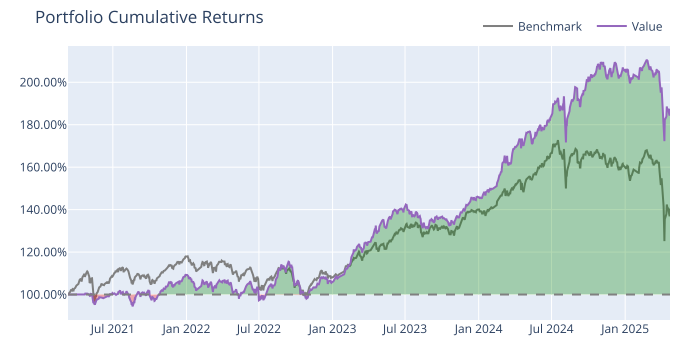

In [33]:
# import plotly.graph_objects as go
fig = pf_factor.plot_cum_returns(title='Portfolio Cumulative Returns')
# fig = go.Figure(fig)
fig.update_layout(yaxis_tickformat='.2%')
show_plotly(fig)     # fig_name='signal_cum_ret'

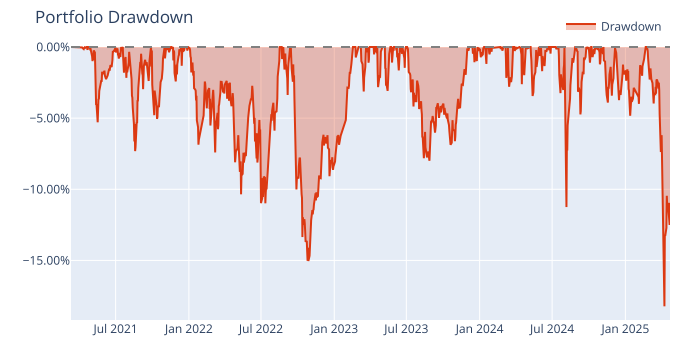

In [34]:
# 回撤深度（相對歷史高點跌幅）
fig = pf_factor.plot_underwater(title='Portfolio Drawdown')
fig.update_layout(yaxis_tickformat='.2%')
show_plotly(fig)    # fig_name='signal_drawdown'

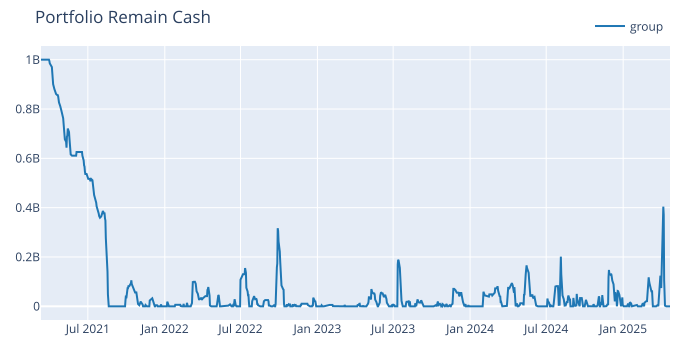

In [35]:
fig = pf_factor.cash().vbt.plot(title='Portfolio Remain Cash')
show_plotly(fig)

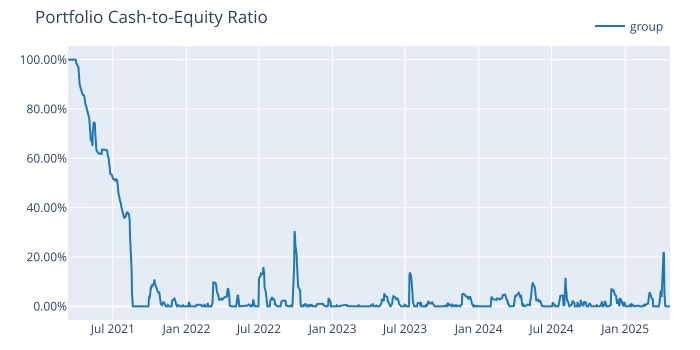

In [36]:
fig = (pf_factor.cash()/pf_factor.value()).vbt.plot(title='Portfolio Cash-to-Equity Ratio')
fig.update_layout(yaxis_tickformat='.2%')
show_plotly(fig)     # fig_name='signal_cash2equity'

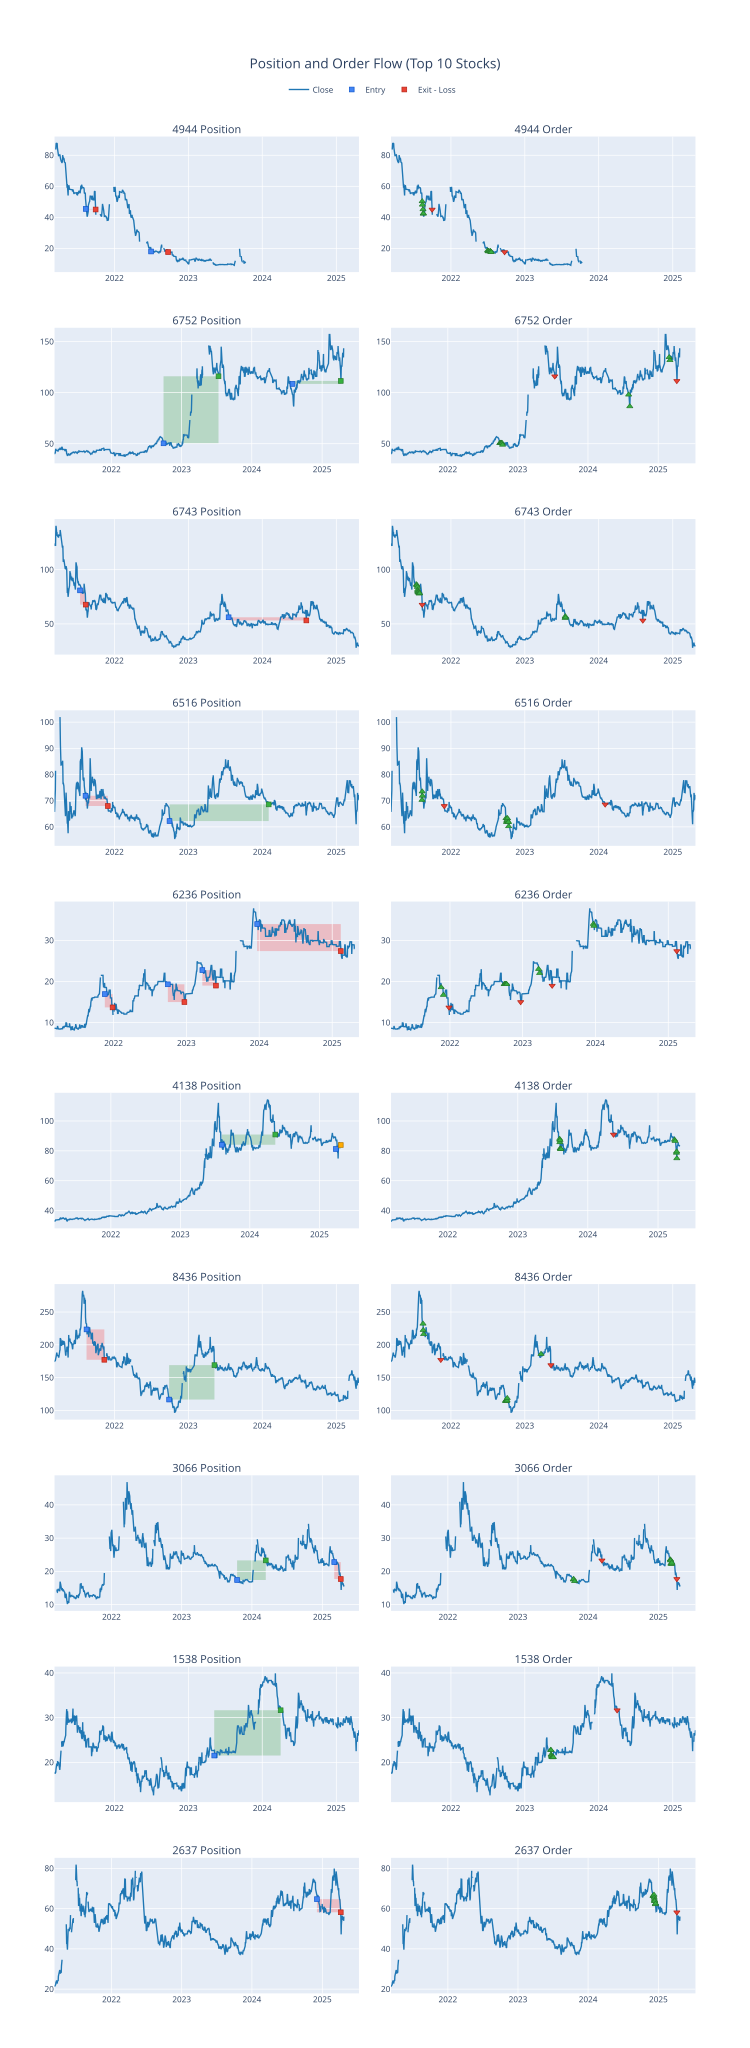

In [37]:
# 個股的部位變化(Position)與訂單進出倉變化(Order)的結果（選取投資總金額前10高的個股）
from plotly.subplots import make_subplots
np.random.seed(320)
n = 10
# ticker_chosen = np.random.choice(trade_ticker_order, n, p = ticker_order_buy/sum(ticker_order_buy) ,replace=False)
ticker_chosen = ticker_order_capital.sort_values(ascending=False).head(n).index
fig = make_subplots(rows=n, cols=2, 
                    horizontal_spacing=0.05,   # 預設 0.2，改小會讓子圖更寬
                    vertical_spacing=0.03,     # 改小會讓子圖更高
                    subplot_titles=sum(
                        [[f'{i} Position', f'{i} Order'] for i in ticker_chosen]
                        , [])  # sum(,[])是把nested list unnest
                    )

# 旗標：只顯示一次圖例
legend_shown = False

for row, ticker in enumerate(ticker_chosen):
    for col, data_type in enumerate(['positions', 'orders']):
        
        if data_type == 'positions':
            subfig = pf_factor.positions.plot(ticker)
        else:
            subfig = pf_factor.orders.plot(ticker)

        subplot_idx = row * 2 + col + 1

        # 設定 subplot 對應的 xref/yref 名稱
        xref = f'x{subplot_idx if subplot_idx > 1 else ""}'
        yref = f'y{subplot_idx if subplot_idx > 1 else ""}'

        for trace in subfig.data:
            # 只保留第一次圖例，其餘關掉
            trace.showlegend = not legend_shown
            fig.add_trace(trace, row=row+1, col=col+1)

        legend_shown = True  # 之後就不再顯示圖例        

        # 加入該子圖的所有 shape（如果有）
        if 'shapes' in subfig.layout:
            for shape in subfig.layout.shapes:
                # shape = shape.copy()  # 避免修改原物件
                shape['xref'] = xref
                shape['yref'] = yref
                fig.add_shape(shape, row=row+1, col=col+1)    
        
        # fig_adj_xaxis_subplot(fig, subplot_idx)

# 調整 legend 到圖的上方
fig.update_layout(
    title = dict(
        text=f"Position and Order Flow (Top {n} Stocks)",
        x=0.5,  # 水平置中
        xanchor='center',
        font=dict(size=20)
    ),
    margin = dict(t=200),
    height=300*n,
    width=1100,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

show_plotly(fig)    # fig_name='signal_pos_ord_flow'
